# Predicció de Resultats de Tennis amb XGBoost

Aquest notebook implementa un model de predicció de resultats de partits de tennis utilitzant XGBoost. El treball inclou:

1. **Càrrega i preparació de dades**: Filtrat per superfície i ordenació temporal
2. **Càlcul de característiques Elo**: Sistema de ranking dinàmic per jugadors
3. **Entrenament de models XGBoost**: Amb validació temporal i calibratge
4. **Prediccions per ronda**: Evaluació del model en cada fase d'un torneig (Wimbledon 2025)

## Estructura del treball

- **Part 1**: Model inicial amb validació temporal (80% train / 20% test)
- **Part 2**: Optimització d'hiperparàmetres i calibratge
- **Part 3**: Prediccions per ronda amb reentrenament incremental


## 1. Càrrega i preparació de dades

Primer de tot, carreguem el dataset i el filtrem per la superfície d'interès (herba, Surface=2).


In [37]:
import pandas as pd
import numpy as np

df_origin = pd.read_csv('wimbeldon_dataset_all_surfaces_v2.csv')
df_origin.head()


C:\Users\ikerr\AppData\Local\Temp\ipykernel_36236\3639339061.py:4: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_origin = pd.read_csv('wimbeldon_dataset_all_surfaces_v2.csv')


,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,CBW,CBL,GBW,GBL,IWW,IWL,SBW,SBL,B365W,B365L,B&WW,B&WL,EXW,EXL,PSW,PSL,WPts,LPts,UBW,UBL,LBW,LBL,SJW,SJL,MaxW,MaxL,AvgW,AvgL,BFEW,BFEL,MaxWin,MaxLoss,AvgWin,AvgLoss,PlayerA,PlayerB,RankA,RankB,RankDiff,WinnerBinary,MaxOddsPlayerA,MaxOddsPlayerB,AvgOddsPlayerA,AvgOddsPlayerB,H2H_A_wins,H2H_B_wins,H2H_Diff,WinsA,LossesA,WinsB,LossesB,WinRateA_cum,WinRateB_cum,Form10A,Form10B,RestDaysA,RestDaysB,DiffWR,DiffForm,DiffRest,LogRankDiff,H2HDiff,ProbA_odds,ProbB_odds,OddsProbDiff,WinRateA_x_Rank,WinRateB_x_Rank,EfficiencyDiff,EloA_Global,EloB_Global,EloA_Surface,EloB_Surface,EloDiff_Global,EloDiff_Surface
0,2,Chennai,Gold Flake Open,2000-01-03,International,1,3,1st Round,3.0,Agenor R.,Kumar S.,94.0,1198,6.0,4.0,6.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Agenor R.,Kumar S.,94.0,1198.0,-1104.0,1,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0.5,0.5,0.5,0.5,30,30,0.0,0.0,0,-2.545114,0,0.333333,0.333333,0.0,0.005319,0.000500,0.004819,1500.0,1500.0,1500.0,1500.0,0.0,0.0
1,1,Adelaide,Australian Hardcourt Championships,2000-01-03,International,1,3,1st Round,3.0,Norman M.,Draper S.,15.0,155,6.0,4.0,6.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Draper S.,Norman M.,155.0,15.0,140.0,0,NaN,NaN,NaN,NaN,0,0,0,0,0,1,1,0.5,0.5,0.5,0.5,30,0,0.0,0.0,30,2.335375,0,0.333333,0.333333,0.0,0.003226,0.033333,-0.030108,1500.0,1500.0,1500.0,1500.0,0.0,0.0
2,2,Chennai,Gold Flake Open,2000-01-03,International,1,3,1st Round,3.0,Golmard J.,Spottl M.,38.0,200,6.0,3.0,6.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Golmard J.,Spottl M.,38.0,200.0,-162.0,1,NaN,NaN,NaN,NaN,0,0,0,2,0,0,0,1.0,0.5,1.0,0.5,0,30,0.5,0.5,-30,-1.660731,0,0.333333,0.333333,0.0,0.026316,0.002500,0.023816,1500.0,1500.0,1500.0,1500.0,0.0,0.0
3,2,Chennai,Gold Flake Open,2000-01-03,International,1,3,1st Round,3.0,Jonsson F.,Kroslak J.,127.0,103,6.0,3.0,6.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jonsson F.,Kroslak J.,127.0,103.0,24.0,1,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0.5,0.5,0.5,0.5,30,30,0.0,0.0,0,0.209458,0,0.333333,0.333333,0.0,0.003937,0.004854,-0.000917,1500.0,1500.0,1500.0,1500.0,0.0,0.0
4,2,Chennai,Gold Flake Open,2000-01-03,International,1,3,1st Round,3.0,Pioline C.,Ram A.,14.0,414,6.0,3.0,6.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pioline C.,Ram A.,14.0,414.0,-400.0,1,NaN,NaN,NaN,NaN,0,0,0,1,1,0,0,0.5,0.5,0.5,0.5,0,30,0.0,0.0,-30,-3.386809,0,0.333333,0.333333,0.0,0.035714,0.001208,0.034507,1500.0,1500.0,1500.0,1500.0,0.0,0.0


In [38]:
# Ens tenim que quedar amb només les dades de tots aquests partits que la seva data és anterior al 2025-06-29
df = df_origin.copy()
#df = df_origin[df_origin['Date'] < '2025-06-29'].copy()
df = df[df['Surface'] == 2].copy()  # Filtrar per herba (Surface = 2)

df.tail()
#print("Mida del df: ", len(df))


,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,CBW,CBL,GBW,GBL,IWW,IWL,SBW,SBL,B365W,B365L,B&WW,B&WL,EXW,EXL,PSW,PSL,WPts,LPts,UBW,UBL,LBW,LBL,SJW,SJL,MaxW,MaxL,AvgW,AvgL,BFEW,BFEL,MaxWin,MaxLoss,AvgWin,AvgLoss,PlayerA,PlayerB,RankA,RankB,RankDiff,WinnerBinary,MaxOddsPlayerA,MaxOddsPlayerB,AvgOddsPlayerA,AvgOddsPlayerB,H2H_A_wins,H2H_B_wins,H2H_Diff,WinsA,LossesA,WinsB,LossesB,WinRateA_cum,WinRateB_cum,Form10A,Form10B,RestDaysA,RestDaysB,DiffWR,DiffForm,DiffRest,LogRankDiff,H2HDiff,ProbA_odds,ProbB_odds,OddsProbDiff,WinRateA_x_Rank,WinRateB_x_Rank,EfficiencyDiff,EloA_Global,EloB_Global,EloA_Surface,EloB_Surface,EloDiff_Global,EloDiff_Surface
68317,36,London,Wimbledon,2025-07-09,Grand Slam,1,2,Quarterfinals,5.0,Djokovic N.,Cobolli F.,6.0,24.0,6.0,7.0,6.0,2.0,7.0,5.0,6.0,4.0,NaN,NaN,3.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.10,7.00,NaN,NaN,NaN,NaN,1.11,8.33,4630.0,2035.0,NaN,NaN,NaN,NaN,NaN,NaN,1.12,8.60,1.09,7.53,NaN,NaN,1.11,8.33,1.105,7.665,Cobolli F.,Djokovic N.,24.0,6.0,18.0,0,8.60,1.12,7.53,1.09,0,1,-1,59,49,1093,215,0.546296,0.835627,0.7,0.9,2,2,-0.289331,-0.2,0,1.386294,-1,0.116279,0.892857,-0.776578,0.022762,0.139271,-0.116509,1788.861188,2026.536109,1556.528325,1975.161612,-237.674922,-418.633287
68318,36,London,Wimbledon,2025-07-09,Grand Slam,1,2,Quarterfinals,5.0,Sinner J.,Shelton B.,1.0,10.0,7.0,6.0,6.0,4.0,6.0,4.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.25,3.60,NaN,NaN,NaN,NaN,1.32,3.60,10430.0,3130.0,NaN,NaN,NaN,NaN,NaN,NaN,1.34,3.90,1.29,3.58,NaN,NaN,1.32,3.60,1.285,3.600,Shelton B.,Sinner J.,10.0,1.0,9.0,0,3.90,1.34,3.58,1.29,1,5,-4,93,65,272,86,0.588608,0.759777,0.6,0.8,2,2,-0.171169,-0.2,0,2.302585,-4,0.256410,0.746269,-0.489858,0.058861,0.759777,-0.700916,1786.399787,2185.560132,1541.645698,1688.214627,-399.160345,-146.568929
68319,36,London,Wimbledon,2025-07-11,Grand Slam,1,2,Semifinals,5.0,Sinner J.,Djokovic N.,1.0,6.0,6.0,3.0,6.0,3.0,6.0,4.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.40,2.80,NaN,NaN,NaN,NaN,1.47,2.93,10430.0,4630.0,NaN,NaN,NaN,NaN,NaN,NaN,1.47,3.05,1.42,2.85,NaN,NaN,1.47,2.93,1.435,2.865,Djokovic N.,Sinner J.,6.0,1.0,5.0,0,3.05,1.47,2.85,1.42,4,4,0,1094,215,273,86,0.835752,0.760446,0.9,0.8,2,2,0.075307,0.1,0,1.791759,0,0.327869,0.680272,-0.352403,0.139292,0.760446,-0.621154,2033.029427,2188.482031,1977.139810,1695.432680,-155.452604,281.707130
68320,36,London,Wimbledon,2025-07-11,Grand Slam,1,2,Semifinals,5.0,Alcaraz C.,Fritz T.,2.0,5.0,6.0,4.0,5.0,7.0,6.0,3.0,7.0,6.0,NaN,NaN,3.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.17,4.75,NaN,NaN,NaN,NaN,1.20,5.13,9300.0,4635.0,NaN,NaN,NaN,NaN,NaN,NaN,1.24,5.25,1.17,4.98,NaN,NaN,1.20,5.13,1.185,4.940,Alcaraz C.,Fritz T.,2.0,5.0,-3.0,1,1.24,5.25,1.17,4.98,1,0,1,239,59,289,189,0.802013,0.604603,1.0,0.9,3,3,0.197411,0.1,0,-0.916291,1,0.806452,0.190476,0.615975,0.401007,0.120921,0.280086,2162.047337,1922.449366,1797.524462,1731.007990,239.597971,66.516471
68321,36,London,Wimbledon,2025-07-13,Grand Slam,1,2,The Final,5.0,Sinner J.,Alcaraz C.,1.0,2.0,4.0,6.0,6.0,4.0,6.0,4.0,6.0,4.0,NaN,NaN,3.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.83,2.00,NaN,NaN,NaN,NaN,1.85,2.07,10430.0,9300.0,NaN,NaN,NaN,NaN,NaN,NaN,1.87,2.07,1.82,1.98,NaN,NaN,1.85,2.07,1.840,2.035,Alcaraz C.,Sinner J.,2.0,1.0,1.0,0,2.07,1.87,1.98,1.82,8,4,4,240,59,274,86,0.802676,0.761111,1.0,0.8,2,2,0.041564,0.2,0,0.693147,4,0.483092,0.534759,-0.051668,0.401338,0.761111,-0.359773,2168.483549,2197.765504,1807.254728,1715.473177,-29.281955,91.781551


## 2. Model XGBoost inicial amb validació temporal

Aquest model utilitza una divisió temporal (80% train / 20% test) per avaluar el rendiment del model XGBoost amb calibratge isotònic.


In [39]:
from collections import defaultdict
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split, TimeSeriesSplit

features = [
    'LogRankDiff',      # ranking
    'DiffWR',           # diferencia de winrate históric en herva
    'DiffForm',         # últims 10
    'H2HDiff',          # head-to-head
    'OddsProbDiff',     # diferencia de probabilitat implícita de quotas
    'DiffRest',         # dies de rest
    'EfficiencyDiff',   # winrate / rank → jugador que rendeix per sobre del seu ranking
    'RankDiff',         # diferencia de ranking
    'EloDiff_Global',   # diferencia de elo global
    'EloDiff_Surface'   # diferencia de elo en superfície
]

df = df.sort_values("Date", ascending=True).reset_index(drop=True)

# Divisió temporal (80% train / 20% test)
X = df[features]
y = df["WinnerBinary"]
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Escalat de les característiques
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Model base XGBoost
base_model = XGBClassifier(
    n_estimators=500,                    # Nombre total d'arbres (boosting rounds) que es construiran. 500 és un valor força alt, bo per a un bon rendiment si es controla l'overfitting.
    max_depth=6,                         # Profunditat màxima de cada arbre. 6 és un valor moderat: permet interaccions complexes sense fer els arbres excessivament profunds.
    learning_rate=0.02,                  # Taxa d'aprenentatge (eta). 0.02 és bastant baixa → aprenentatge lent i estable, ideal quan tens molts estimators (500).
    subsample=0.85,                      # Percentatge de mostres (files) que s'utilitzen per entrenar cada arbre. 0.85 = 85% → ajuda a reduir overfitting i afegeix variància (com bagging).
    colsample_bytree=0.85,               # Percentatge de columnes (variables) que s'agafen aleatòriament per cada arbre. 85% → també redueix overfitting i millora la generalització.
    min_child_weight=5,                  # Suma mínima del pes Hessiana en un node fill. Valors >1 fan el model més conservador: evita dividir nodes amb poca informació.
    gamma=0.1,                           # Minimització mínima de la funció de pèrdua necessària per fer una partició addicional (regularització per poda). 0.1 afavoreix arbres més simples.
    reg_alpha=0.1,                       # Terme de regularització L1 sobre els pesos de les fulles. Ajuda a fer sparseness i és útil quan hi ha moltes variables irrellevants.
    reg_lambda=1.0,                      # Terme de regularització L2 (més suau que L1). 1.0 és el valor per defecte i sol funcionar bé en la majoria de casos.
    random_state=42,                     # Llavor per a la reproductibilitat dels resultats (aleatorietat controlada).
    n_jobs=-1,                           # Utilitza tots els nuclis disponibles del processador per entrenar en paral·lel → molt més ràpid.
    eval_metric='logloss'                # Mètrica d'avaluació durant l'entrenament (per classificació binària/multiclasse). 'logloss' = logarithmic loss (cross-entropy).
)

# Calibratge isotònic per millorar la calibració de les probabilitats
tscv = TimeSeriesSplit(n_splits=5)
model = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
model.fit(X_train_sc, y_train)

# Prediccions i avaluació
pred = model.predict(X_test_sc)
prob_model_con_tscv = model.predict_proba(X_test_sc)[:, 1]
acc = accuracy_score(y_test, pred)
brier = brier_score_loss(y_test, prob_model_con_tscv)

print("\n" + "="*80)
print(f"ACCURACY FINAL TEST CRONOLÓGIC: {acc:.4f}")
print(f"Brier Score: {brier:.4f}")
print(classification_report(y_test, pred, digits=4))
print("="*80)



ACCURACY FINAL TEST CRONOLÓGIC: 0.6768
Brier Score: 0.2034
              precision    recall  f1-score   support

           0     0.6753    0.6317    0.6528       744
           1     0.6780    0.7186    0.6977       803

    accuracy                         0.6768      1547
   macro avg     0.6767    0.6751    0.6752      1547
weighted avg     0.6767    0.6768    0.6761      1547



### 2.1. Anàlisi d'importància de característiques amb SHAP

SHAP (SHapley Additive exPlanations) ens permet entendre la importància de cada característica en les prediccions del model.


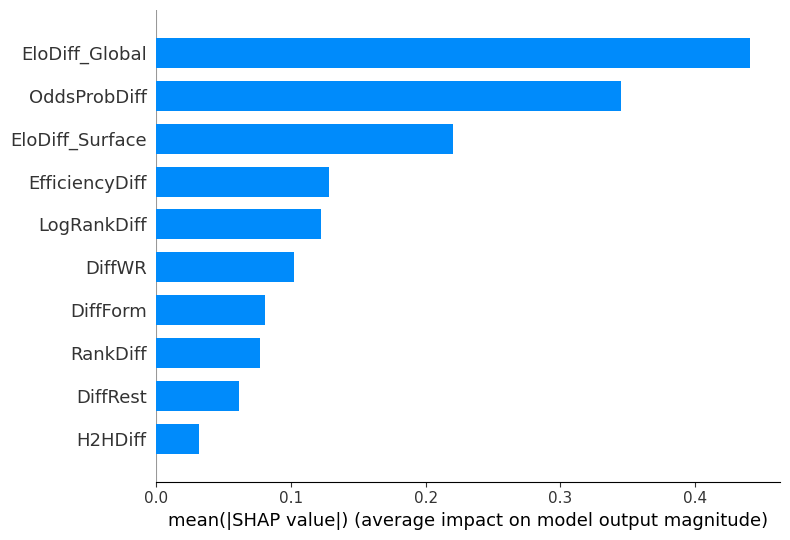

In [40]:
import shap

# Extreure el model XGBoost del calibratge per utilitzar SHAP
xgb_model = model.calibrated_classifiers_[0].estimator

# Crear l'explicador SHAP i calcular els valors
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_sc)

# Visualització de la importància de característiques
shap.summary_plot(shap_values, X_train, plot_type="bar")


## 3. Càlcul de característiques Elo

El sistema Elo és un mètode de ranking dinàmic que actualitza la puntuació dels jugadors segons els resultats dels partits. Implementem un sistema avançat amb:

- **Elo Global**: Ranking general del jugador
- **Elo per Superfície**: Ranking específic per tipus de superfície (herba, terra, etc.)
- **Actualització dinàmica**: El K factor varia segons la diferència d'Elo entre jugadors
- **Importància del torneig**: Els torneigs majors (Grand Slam, Masters) tenen més pes


In [41]:
from collections import defaultdict

# ============================
# 1. MAPEO SUPERFICIES SI ESTÁN NUMERIZADAS
# ============================

# Si Surface es numérica (LabelEncoder), necesitamos mapearlo a strings
surface_map = {
    0: "Hard",
    1: "Clay",
    2: "Grass",
    3: "Carpet"
}

# Detectar si Surface es numérica
if np.issubdtype(df["Surface"].dtype, np.number):
    df["SurfaceText"] = df["Surface"].map(surface_map)
else:
    df["SurfaceText"] = df["Surface"]

# ============================
# 2. ORDEN CORRECTO DE RONDAS
# ============================

round_order = {
    "1st Round": 1,
    "2nd Round": 2,
    "3rd Round": 3,
    "4th Round": 4,
    "Round of 16": 5,
    "Quarterfinals": 6,
    "Semifinals": 7,
    "The Final": 8
}

df["RoundOrder"] = df["Round"].map(round_order)

# Ordenar completamente en orden real cronológico
df = df.sort_values(["Date", "Tournament", "RoundOrder"]).reset_index(drop=True)

# ============================
# 3. CONFIGURACIÓN DEL ELO
# ============================

ELO_START = 1500
DECAY_GLOBAL = 0.9995
DECAY_SURFACE = 0.999

def dynamic_k(diff):
    """K depende de diferencia de Elo (más cerca → más grande K)."""
    if diff < 25:
        return 40
    elif diff < 75:
        return 32
    elif diff < 150:
        return 24
    else:
        return 16

# Importancia del torneo
tournament_weights = {
    "ATP250": 1.00,
    "ATP500": 1.10,
    "Masters 1000": 1.20,
    "Grand Slam": 1.30,
    "International": 1.00   # por compatibilidad con tus datos antiguos
}

# ============================
# 4. INICIALIZAR ELO
# ============================

elo_global = defaultdict(lambda: ELO_START)
elo_surface = defaultdict(lambda: {"Hard": ELO_START, "Clay": ELO_START, "Grass": ELO_START, "Carpet": ELO_START})

# Columnas de salida
df["EloA_Global"] = 0.0
df["EloB_Global"] = 0.0
df["EloA_Surface"] = 0.0
df["EloB_Surface"] = 0.0

# ============================
# 5. EXPECTED SCORE
# ============================

def expected_score(r1, r2):
    return 1 / (1 + 10 ** ((r2 - r1) / 400))

# ============================
# 6. CALCULAR ELO SIN DATA LEAKAGE
# ============================

for i, row in df.iterrows():
    
    A = row["PlayerA"]
    B = row["PlayerB"]
    surf = row["SurfaceText"]
    series = row["Series"]

    # --- Decaimiento temporal (antes del partido)
    elo_global[A] *= DECAY_GLOBAL
    elo_global[B] *= DECAY_GLOBAL
    elo_surface[A][surf] *= DECAY_SURFACE
    elo_surface[B][surf] *= DECAY_SURFACE

    # --- Elo ANTES DEL PARTIDO (features pre-partido)
    eloA_g = elo_global[A]
    eloB_g = elo_global[B]
    eloA_s = elo_surface[A][surf]
    eloB_s = elo_surface[B][surf]

    df.at[i, "EloA_Global"] = eloA_g
    df.at[i, "EloB_Global"] = eloB_g
    df.at[i, "EloA_Surface"] = eloA_s
    df.at[i, "EloB_Surface"] = eloB_s

    # --- Resultado del partido
    winner = row["WinnerBinary"]
    scoreA = 1 if winner == 1 else 0
    scoreB = 1 - scoreA

    # --- Expected score
    expA_g = expected_score(eloA_g, eloB_g)
    expA_s = expected_score(eloA_s, eloB_s)

    # --- K dinámico + importancia de torneo
    diff = abs(eloA_g - eloB_g)
    K = dynamic_k(diff)
    weight = tournament_weights.get(series, 1.00)
    K_final = K * weight

    # --- Actualización GLOBAL
    elo_global[A] = eloA_g + K_final * (scoreA - expA_g)
    elo_global[B] = eloB_g + K_final * (scoreB - (1 - expA_g))

    # --- Actualización SUPERFICIE
    elo_surface[A][surf] = eloA_s + K_final * (scoreA - expA_s)
    elo_surface[B][surf] = eloB_s + K_final * (scoreB - (1 - expA_s))

# ============================
# 7. DIFERENCIAS FINALES COMO FEATURES
# ============================

df["EloDiff_Global"] = df["EloA_Global"] - df["EloB_Global"]
df["EloDiff_Surface"] = df["EloA_Surface"] - df["EloB_Surface"]

df.head()


,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,CBW,CBL,GBW,GBL,IWW,IWL,SBW,SBL,B365W,B365L,B&WW,B&WL,EXW,EXL,PSW,PSL,WPts,LPts,UBW,UBL,LBW,LBL,SJW,SJL,MaxW,MaxL,AvgW,AvgL,BFEW,BFEL,MaxWin,MaxLoss,AvgWin,AvgLoss,PlayerA,PlayerB,RankA,RankB,RankDiff,WinnerBinary,MaxOddsPlayerA,MaxOddsPlayerB,AvgOddsPlayerA,AvgOddsPlayerB,H2H_A_wins,H2H_B_wins,H2H_Diff,WinsA,LossesA,WinsB,LossesB,WinRateA_cum,WinRateB_cum,Form10A,Form10B,RestDaysA,RestDaysB,DiffWR,DiffForm,DiffRest,LogRankDiff,H2HDiff,ProbA_odds,ProbB_odds,OddsProbDiff,WinRateA_x_Rank,WinRateB_x_Rank,EfficiencyDiff,EloA_Global,EloB_Global,EloA_Surface,EloB_Surface,EloDiff_Global,EloDiff_Surface,SurfaceText,RoundOrder
0,33,Halle,Gerry Weber Open,2000-06-12,International,1,2,1st Round,3.0,Federer R.,Clement A.,38.0,57,6.0,4.0,6.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Clement A.,Federer R.,57.0,38.0,19.0,0,NaN,NaN,NaN,NaN,1,0,1,9,12,16,13,0.428571,0.551724,0.400000,0.4,14,14,-0.123153,0.000000,0,0.405465,1,0.333333,0.333333,0.0,0.007519,0.014519,-0.007000,1499.25,1499.25,1498.5,1498.5,0.0,0.0,Grass,1
1,33,Halle,Gerry Weber Open,2000-06-12,International,1,2,1st Round,3.0,Kafelnikov Y.,Vicente F.,5.0,29,6.0,7.0,7.0,6.0,6.0,4.0,NaN,NaN,NaN,NaN,2.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kafelnikov Y.,Vicente F.,5.0,29.0,-24.0,1,NaN,NaN,NaN,NaN,1,0,1,24,14,18,16,0.631579,0.529412,0.600000,0.5,14,14,0.102167,0.100000,0,-1.757858,1,0.333333,0.333333,0.0,0.126316,0.018256,0.108060,1499.25,1499.25,1498.5,1498.5,0.0,0.0,Grass,1
2,33,Halle,Gerry Weber Open,2000-06-12,International,1,2,1st Round,3.0,Larsson M.,Ferrero J.C.,49.0,12,6.0,3.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ferrero J.C.,Larsson M.,12.0,49.0,-37.0,0,NaN,NaN,NaN,NaN,0,0,0,29,13,12,5,0.690476,0.705882,0.700000,0.6,14,56,-0.015406,0.100000,-42,-1.406914,0,0.333333,0.333333,0.0,0.057540,0.014406,0.043134,1499.25,1499.25,1498.5,1498.5,0.0,0.0,Grass,1
3,33,Halle,Gerry Weber Open,2000-06-12,International,1,2,1st Round,3.0,Moya C.,Caratti C.,51.0,153,6.0,2.0,6.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Caratti C.,Moya C.,153.0,51.0,102.0,0,NaN,NaN,NaN,NaN,0,0,0,1,2,15,9,0.333333,0.625000,0.333333,0.5,119,14,-0.291667,-0.166667,105,1.098612,0,0.333333,0.333333,0.0,0.002179,0.012255,-0.010076,1499.25,1499.25,1498.5,1498.5,0.0,0.0,Grass,1
4,33,Halle,Gerry Weber Open,2000-06-12,International,1,2,1st Round,3.0,Chang M.,Tillstrom M.,28.0,59,6.0,3.0,3.0,6.0,6.0,3.0,NaN,NaN,NaN,NaN,2.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chang M.,Tillstrom M.,28.0,59.0,-31.0,1,NaN,NaN,NaN,NaN,0,1,-1,16,12,12,9,0.571429,0.571429,0.500000,0.5,14,14,0.000000,0.000000,0,-0.745333,-1,0.333333,0.333333,0.0,0.020408,0.009685,0.010723,1499.25,1499.25,1498.5,1498.5,0.0,0.0,Grass,1


## 4. Optimització d'hiperparàmetres i calibratge

Aquesta secció optimitza el nombre d'estimadors (n_estimators) de XGBoost utilitzant una divisió 70% train / 10% validation / 20% test. Després aplica calibratge isotònic per millorar la calibració de les probabilitats.


In [42]:
from sklearn.preprocessing import LabelEncoder

le_series = LabelEncoder()
df["Series"] = le_series.fit_transform(df["Series"])

# ======== FEATURES ========
features = [
    # Diferencias estadísticas base
    'LogRankDiff',
    'DiffWR',
    'DiffForm',
    'H2HDiff',
    'OddsProbDiff',
    'DiffRest',
    'EfficiencyDiff',
    'RankDiff',

    # Elo avanzado
    'EloDiff_Global',
    'EloDiff_Surface',

    # Contexto
    'Series',       # codificada con LabelEncoder
    'RoundOrder'    # orden real de la ronda
]

# Aseguramos orden temporal
df = df.sort_values("Date", ascending=True).reset_index(drop=True)

X = df[features]
y = df["WinnerBinary"].values

n = len(df)
idx_train_end = int(n * 0.7)   # 70% train
idx_val_end   = int(n * 0.8)   # 10% val (70–80)
# 20% restante = test

X_train = X.iloc[:idx_train_end]
y_train = y[:idx_train_end]

X_val   = X.iloc[idx_train_end:idx_val_end]
y_val   = y[idx_train_end:idx_val_end]

X_test  = X.iloc[idx_val_end:]
y_test  = y[idx_val_end:]

print("Tamaños:")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# ======== ESCALADO (solo con TRAIN) ========
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)


Tamaños:
Train: (5413, 12) Val: (774, 12) Test: (1547, 12)


### 4.1. Búsqueda del millor n_estimators

Avaluem diferents valors de `n_estimators` per trobar el que minimitza el Brier Score en el conjunt de validació.


In [ ]:
from copy import deepcopy

# Valores a probar para número de árboles
n_estimators_grid = [200, 350, 500, 750, 1000, 1300]

results = []

for n_est in n_estimators_grid:
    print(f"\nEntrenando modelo con n_estimators = {n_est}")

    model_tmp = XGBClassifier(
        n_estimators=n_est,
        max_depth=6,
        learning_rate=0.02,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=5,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    )


    model_tmp.fit(X_train_sc, y_train)

    prob_val = model_tmp.predict_proba(X_val_sc)[:, 1]
    pred_val = (prob_val >= 0.5).astype(int)

    acc_val = accuracy_score(y_val, pred_val)
    brier_val = brier_score_loss(y_val, prob_val)

    results.append((n_est, acc_val, brier_val))
    print(f"VAL → ACC={acc_val:.4f}, BRIER={brier_val:.4f}")

# Elegir el mejor por Brier y, en empate, por accuracy
results_sorted = sorted(results, key=lambda x: (x[2], -x[1]))
best_n, best_acc_val, best_brier_val = results_sorted[0]

print("\n==============================")
print("MEJOR n_estimators EN VALIDACIÓN:")
print(f"n_estimators={best_n}, ACC_VAL={best_acc_val:.4f}, BRIER_VAL={best_brier_val:.4f}")
print("==============================")



Entrenando modelo con n_estimators = 200
VAL → ACC=0.6835, BRIER=0.2068

Entrenando modelo con n_estimators = 350
VAL → ACC=0.6886, BRIER=0.2092

Entrenando modelo con n_estimators = 500
VAL → ACC=0.6899, BRIER=0.2109

Entrenando modelo con n_estimators = 750
VAL → ACC=0.6835, BRIER=0.2148

Entrenando modelo con n_estimators = 1000
VAL → ACC=0.6809, BRIER=0.2177

Entrenando modelo con n_estimators = 1300
VAL → ACC=0.6757, BRIER=0.2218

MEJOR n_estimators EN VALIDACIÓN:
n_estimators=200, ACC_VAL=0.6835, BRIER_VAL=0.2068


### 4.2. Model final sense calibratge

Entrenem el model amb el millor `n_estimators` trobat, utilitzant train+validation, i l'avaluem en el test.


In [44]:
# ======== REENTRENAR SCALER EN TRAIN+VAL ========
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = np.concatenate([y_train, y_val])

scaler_final = StandardScaler()
X_train_val_sc = scaler_final.fit_transform(X_train_val)
X_test_sc_final = scaler_final.transform(X_test)

# ======== MODELO XGBOOST FINAL (SIN CALIBRACIÓN) ========
base_model_final = XGBClassifier(
    n_estimators=best_n,
    max_depth=6,
    learning_rate=0.02,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

base_model_final.fit(X_train_val_sc, y_train_val)

# ======== EVALUACIÓN SIN CALIBRACIÓN ========
prob_test_base = base_model_final.predict_proba(X_test_sc_final)[:, 1]
pred_test_base = (prob_test_base >= 0.5).astype(int)

acc_base = accuracy_score(y_test, pred_test_base)
brier_base = brier_score_loss(y_test, prob_test_base)

print("\n===== RESULTADOS SIN CALIBRACIÓN =====")
print(f"Accuracy TEST: {acc_base:.4f}")
print(f"Brier TEST:    {brier_base:.4f}")
print(classification_report(y_test, pred_test_base, digits=4))
print("=======================================")



===== RESULTADOS SIN CALIBRACIÓN =====
Accuracy TEST: 0.6690
Brier TEST:    0.2042
              precision    recall  f1-score   support

           0     0.6593    0.6452    0.6522       744
           1     0.6777    0.6912    0.6843       803

    accuracy                         0.6690      1547
   macro avg     0.6685    0.6682    0.6683      1547
weighted avg     0.6688    0.6690    0.6689      1547



Com podem veure, l'Accuracy no millora, i el Brier tampoc.

### 4.3. Model final amb calibratge isotònic

El calibratge isotònic millora la calibració de les probabilitats del model. Observem com afecta el rendiment.


In [45]:
# ======== CALIBRACIÓN ISOTÓNICA SOBRE TRAIN+VAL ========
cal_model = CalibratedClassifierCV(
    estimator=deepcopy(base_model_final),
    method="isotonic",
    cv=5
)

cal_model.fit(X_train_val_sc, y_train_val)

prob_test_cal = cal_model.predict_proba(X_test_sc_final)[:, 1]
pred_test_cal = (prob_test_cal >= 0.5).astype(int)

acc_cal = accuracy_score(y_test, pred_test_cal)
brier_cal = brier_score_loss(y_test, prob_test_cal)

print("\n===== RESULTADOS CON CALIBRACIÓN ISOTÓNICA =====")
print(f"Accuracy TEST: {acc_cal:.4f}")
print(f"Brier TEST:    {brier_cal:.4f}")
print(classification_report(y_test, pred_test_cal, digits=4))
print("================================================")



===== RESULTADOS CON CALIBRACIÓN ISOTÓNICA =====
Accuracy TEST: 0.6742
Brier TEST:    0.2028
              precision    recall  f1-score   support

           0     0.6695    0.6371    0.6529       744
           1     0.6782    0.7086    0.6931       803

    accuracy                         0.6742      1547
   macro avg     0.6738    0.6728    0.6730      1547
weighted avg     0.6740    0.6742    0.6737      1547



En aquest cas, el Brier és inferior, però la diferencia és tan petita que tampoc ho tindrem en compte.

## 5. Prediccions per ronda (Wimbledon 2025)

En aquesta secció avaluem el model en cada ronda del torneig de Wimbledon 2025. El model es reentrena incrementalment després de cada ronda, afegint les dades de la ronda anterior al conjunt d'entrenament. Això simula com funcionaria en un escenari real on el model aprén a mesura que el torneig progressa.


In [46]:
# Preparació de dades per ronda
train = df[df['Date'] < '2025-06-29'].copy()
test = df[(df['Date'] >= '2025-06-29') & (df['Date'] <= '2025-07-13')].copy()

print("Mida train: ", len(train))
print("Mida test: ", len(test))

train.tail()


Mida train:  7607
Mida test:  127


,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,CBW,CBL,GBW,GBL,IWW,IWL,SBW,SBL,B365W,B365L,B&WW,B&WL,EXW,EXL,PSW,PSL,WPts,LPts,UBW,UBL,LBW,LBL,SJW,SJL,MaxW,MaxL,AvgW,AvgL,BFEW,BFEL,MaxWin,MaxLoss,AvgWin,AvgLoss,PlayerA,PlayerB,RankA,RankB,RankDiff,WinnerBinary,MaxOddsPlayerA,MaxOddsPlayerB,AvgOddsPlayerA,AvgOddsPlayerB,H2H_A_wins,H2H_B_wins,H2H_Diff,WinsA,LossesA,WinsB,LossesB,WinRateA_cum,WinRateB_cum,Form10A,Form10B,RestDaysA,RestDaysB,DiffWR,DiffForm,DiffRest,LogRankDiff,H2HDiff,ProbA_odds,ProbB_odds,OddsProbDiff,WinRateA_x_Rank,WinRateB_x_Rank,EfficiencyDiff,EloA_Global,EloB_Global,EloA_Surface,EloB_Surface,EloDiff_Global,EloDiff_Surface,SurfaceText,RoundOrder
7602,35,Mallorca,Mallorca Championships,2025-06-27,0,1,2,Semifinals,3.0,Griekspoor T.,Auger-Aliassime F.,34.0,27.0,6.0,4.0,6.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.20,1.67,NaN,NaN,NaN,NaN,2.30,1.69,1535.0,1775.0,NaN,NaN,NaN,NaN,NaN,NaN,2.32,1.74,2.18,1.67,NaN,NaN,2.30,1.69,2.250,1.680,Auger-Aliassime F.,Griekspoor T.,27.0,34.0,-7.0,0,1.74,2.32,1.67,2.18,1,0,1,223,148,105,94,0.601078,0.527638,0.6,0.7,1,1,0.073440,-0.1,0,-0.230524,1,0.574713,0.431034,0.143678,0.022262,0.015519,0.006743,1580.733744,1584.770096,1546.867135,1558.348816,-4.036352,-11.481682,Grass,7
7603,34,Eastbourne,Eastbourne International,2025-06-27,0,1,2,Semifinals,3.0,Brooksby J.,Humbert U.,149.0,20.0,6.0,7.0,6.0,4.0,6.0,4.0,NaN,NaN,NaN,NaN,2.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.80,1.44,NaN,NaN,NaN,NaN,2.87,1.48,405.0,2195.0,NaN,NaN,NaN,NaN,NaN,NaN,2.92,1.51,2.76,1.44,NaN,NaN,2.87,1.48,2.835,1.460,Brooksby J.,Humbert U.,149.0,20.0,129.0,1,2.92,1.51,2.76,1.44,0,1,-1,57,39,148,130,0.593750,0.532374,0.8,0.6,1,1,0.061376,0.2,0,2.008214,-1,0.342466,0.662252,-0.319786,0.003985,0.026619,-0.022634,1547.382539,1578.021479,1528.754762,1543.804755,-30.638940,-15.049993,Grass,7
7604,34,Eastbourne,Eastbourne International,2025-06-27,0,1,2,Semifinals,3.0,Fritz T.,Davidovich Fokina A.,5.0,28.0,6.0,3.0,3.0,6.0,6.0,1.0,NaN,NaN,NaN,NaN,2.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.33,3.40,NaN,NaN,NaN,NaN,1.37,3.37,4635.0,1770.0,NaN,NaN,NaN,NaN,NaN,NaN,1.39,3.50,1.34,3.27,NaN,NaN,1.37,3.40,1.350,3.385,Davidovich Fokina A.,Fritz T.,28.0,5.0,23.0,0,3.50,1.39,3.27,1.34,3,1,2,136,126,282,189,0.519084,0.598726,0.6,0.7,1,1,-0.079642,-0.1,0,1.722767,2,0.285714,0.719424,-0.433710,0.018539,0.119745,-0.101207,1480.253671,1684.879730,1462.178174,1646.372594,-204.626059,-184.194419,Grass,7
7605,34,Eastbourne,Eastbourne International,2025-06-28,0,1,2,The Final,3.0,Fritz T.,Brooksby J.,5.0,149.0,7.0,5.0,6.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.30,3.60,NaN,NaN,NaN,NaN,1.30,3.89,4635.0,405.0,NaN,NaN,NaN,NaN,NaN,NaN,1.31,4.10,1.28,3.64,NaN,NaN,1.30,3.89,1.300,3.745,Brooksby J.,Fritz T.,149.0,5.0,144.0,0,4.10,1.31,3.64,1.28,1,1,0,58,39,283,189,0.597938,0.599576,0.8,0.7,1,1,-0.001638,0.1,0,3.394508,0,0.243902,0.763359,-0.519456,0.004013,0.119915,-0.115902,1564.007473,1687.802223,1543.901959,1648.838114,-123.794750,-104.936155,Grass,8
7606,35,Mallorca,Mallorca Championships,2025-06-28,0,1,2,The Final,3.0,Griekspoor T.,Moutet C.,34.0,83.0,7.0,5.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.57,2.30,NaN,NaN,NaN,NaN,1.59,2.46,1535.0,739.0,NaN,NaN,NaN,NaN,NaN,NaN,1.65,2.50,1.56,2.39,NaN,NaN,1.59,2.46,1.580,2.380,Griekspoor T.,Moutet C.,34.0,83.0,-49.0,1,1.65,2.50,1.56,2.39,0,0,0,106,94,78,102,0.530000,0.433333,0.7,0.7,1,1,0.096667,0.0,0,-0.892480,0,0.606061,0.400000,0.206061,0.015588,0.005221,0.010367,1603.735487,1526.599706,1576.110430,1501.686108,77.135780,74.424322,Grass,8


In [47]:
# Separar per rondes
first_round = test[test['Round'] == '1st Round']
second_round = test[test['Round'] == '2nd Round']
third_round = test[test['Round'] == '3rd Round']
fourth_round = test[test['Round'] == '4th Round']
quarter_finals = test[test['Round'] == 'Quarterfinals']
semi_finals = test[test['Round'] == 'Semifinals']
finals = test[test['Round'] == 'The Final']

print("Mida first round: ", len(first_round))
print("Mida second round: ", len(second_round))
print("Mida third round: ", len(third_round))
print("Mida fourth round: ", len(fourth_round))
print("Mida quarter finals: ", len(quarter_finals))
print("Mida semi finals: ", len(semi_finals))
print("Mida finals: ", len(finals))


Mida first round:  64
Mida second round:  32
Mida third round:  16
Mida fourth round:  8
Mida quarter finals:  4
Mida semi finals:  2
Mida finals:  1


### 5.1. Funció d'anàlisi de prediccions

Funció auxiliar per analitzar les prediccions fila a fila, mostrant detalls de cada partit i identificant les prediccions fallides.


In [48]:
from IPython.display import display

def analyze_predictions(
    df,
    y_true,
    y_pred,
    y_prob,
    date_col="Date",
    player_a_col="PlayerA",
    player_b_col="PlayerB",
    true_col_name="WinnerBinary"
):

    # Copia de las columnas de contexto
    results_df = df[[date_col, player_a_col, player_b_col]].copy()
    results_df[true_col_name] = y_true

    # Añadir predicciones y probabilidades
    results_df["Predicted"] = y_pred
    results_df["Probability"] = y_prob

    # Aciertos / fallos
    results_df["Correct"] = (results_df[true_col_name] == results_df["Predicted"])
    results_df["Result"] = results_df["Correct"].map({True: "✓ Correct", False: "✗ Failed"})

    # Resumen global
    total = len(results_df)
    correct = results_df["Correct"].sum()
    incorrect = total - correct
    acc = correct / total if total > 0 else 0.0

    print("RESULTADOS DETALLADOS POR FILA:")
    print("=" * 100)
    print(f"\nTotal de predicciones: {total}")
    print(f"Correctas: {correct} ({acc*100:.2f}%)")
    print(f"Fallidas: {incorrect} ({(1-acc)*100:.2f}%)")
    print("\n" + "=" * 100 + "\n")

    # Mostrar todas las filas
    pd.set_option("display.max_rows", None)
    pd.set_option("display.width", None)
    pd.set_option("display.max_columns", None)

    display(results_df[[date_col, player_a_col, player_b_col,
                        true_col_name, "Predicted", "Probability", "Result"]])

    # Mostrar solo fallos
    print("\n" + "=" * 100)
    print("PREDICCIONES FALLIDAS:")
    print("=" * 100)
    failed_df = results_df[~results_df["Correct"]]

    if len(failed_df) > 0:
        display(failed_df[[date_col, player_a_col, player_b_col,
                           true_col_name, "Predicted", "Probability"]])
    else:
        print("¡Todas las predicciones han sido correctas!")

    return results_df, failed_df


### 5.2. Primera ronda

Comencem a predir els valors de la primera ronda del torneig.

In [49]:
features = [
    # Diferencias estadísticas base
    'LogRankDiff',
    'DiffWR',
    'DiffForm',
    'H2HDiff',
    'OddsProbDiff',
    'DiffRest',
    'EfficiencyDiff',
    'RankDiff',

    # Elo avanzado
    'EloDiff_Global',
    'EloDiff_Surface',

    # Contexto
    'Series',       # codificada con LabelEncoder
    'RoundOrder'    # orden real de la ronda
]

X_train = train[features].fillna(0)
X_test = first_round[features].fillna(0)
y_train = train['WinnerBinary']
y_test = first_round['WinnerBinary']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

base_model = XGBClassifier(
    n_estimators=500,                    # Nombre total d'arbres (boosting rounds) que es construiran. 500 és un valor força alt, bo per a un bon rendiment si es controla l'overfitting.
    max_depth=6,                         # Profunditat màxima de cada arbre. 6 és un valor moderat: permet interaccions complexes sense fer els arbres excessivament profunds.
    learning_rate=0.02,                  # Taxa d'aprenentatge (eta). 0.02 és bastant baixa → aprenentatge lent i estable, ideal quan tens molts estimators (500).
    subsample=0.85,                      # Percentatge de mostres (files) que s'utilitzen per entrenar cada arbre. 0.85 = 85% → ajuda a reduir overfitting i afegeix variància (com bagging).
    colsample_bytree=0.85,               # Percentatge de columnes (variables) que s'agafen aleatòriament per cada arbre. 85% → també redueix overfitting i millora la generalització.
    min_child_weight=5,                  # Suma mínima del pes Hessiana en un node fill. Valors >1 fan el model més conservador: evita dividir nodes amb poca informació.
    gamma=0.1,                           # Minimització mínima de la funció de pèrdua necessària per fer una partició addicional (regularització per poda). 0.1 afavoreix arbres més simples.
    reg_alpha=0.1,                       # Terme de regularització L1 sobre els pesos de les fulles. Ajuda a fer sparseness i és útil quan hi ha moltes variables irrellevants.
    reg_lambda=1.0,                      # Terme de regularització L2 (més suau que L1). 1.0 és el valor per defecte i sol funcionar bé en la majoria de casos.
    random_state=42,                     # Llavor per a la reproductibilitat dels resultats (aleatorietat controlada).
    n_jobs=-1,                           # Utilitza tots els nuclis disponibles del processador per entrenar en paral·lel → molt més ràpid.
    eval_metric='logloss'                # Mètrica d'avaluació durant l'entrenament (per classificació binària/multiclasse). 'logloss' = logarithmic loss (cross-entropy).
)

tscv = TimeSeriesSplit(n_splits=5)

model = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
model.fit(X_train_sc, y_train)

pred = model.predict(X_test_sc)
prob = model.predict_proba(X_test_sc)[:, 1]
acc = accuracy_score(y_test, pred)
brier = brier_score_loss(y_test, prob)

print("\n" + "="*80)
print(f"ACCURACY FINAL TEST CRONOLÓGIC: {acc:.4f}")
print(f"Brier Score: {brier:.4f}")
print(classification_report(y_test, pred, digits=4))
print("="*80)



ACCURACY FINAL TEST CRONOLÓGIC: 0.6562
Brier Score: 0.2410
              precision    recall  f1-score   support

           0     0.6562    0.6562    0.6562        32
           1     0.6562    0.6562    0.6562        32

    accuracy                         0.6562        64
   macro avg     0.6562    0.6562    0.6562        64
weighted avg     0.6562    0.6562    0.6562        64



In [50]:
results_df, failed_df = analyze_predictions(
    df=first_round,
    y_true=first_round["WinnerBinary"].values,
    y_pred=pred,
    y_prob=prob,
    date_col="Date",
    player_a_col="PlayerA",
    player_b_col="PlayerB",
    true_col_name="WinnerBinary"
)


RESULTADOS DETALLADOS POR FILA:

Total de predicciones: 64
Correctas: 42 (65.62%)
Fallidas: 22 (34.38%)




,Date,PlayerA,PlayerB,WinnerBinary,Predicted,Probability,Result
7607,2025-06-30,Brooksby J.,Griekspoor T.,1,0,0.267717,✗ Failed
7608,2025-06-30,Bonzi B.,Medvedev D.,1,0,0.031106,✗ Failed
7609,2025-06-30,Fearnley J.,Fonseca J.,0,0,0.362448,✓ Correct
7610,2025-06-30,Khachanov K.,McDonald M.,1,1,0.557870,✓ Correct
7611,2025-06-30,Moller E.,Tiafoe F.,0,0,0.034460,✓ Correct
7612,2025-06-30,Mannarino A.,O Connell C.,1,1,0.687700,✓ Correct
7613,2025-06-30,Altmaier D.,Diallo G.,0,0,0.196541,✓ Correct
7614,2025-06-30,Royer V.,Tsitsipas S.,1,0,0.210317,✗ Failed
7615,2025-06-30,Dellien H.,Lehecka J.,0,0,0.011226,✓ Correct
7616,2025-06-30,Riedi L.,Tarvet O.,0,1,0.596815,✗ Failed



PREDICCIONES FALLIDAS:


,Date,PlayerA,PlayerB,WinnerBinary,Predicted,Probability
7607,2025-06-30,Brooksby J.,Griekspoor T.,1,0,0.267717
7608,2025-06-30,Bonzi B.,Medvedev D.,1,0,0.031106
7614,2025-06-30,Royer V.,Tsitsipas S.,1,0,0.210317
7616,2025-06-30,Riedi L.,Tarvet O.,0,1,0.596815
7620,2025-06-30,Bautista Agut R.,Norrie C.,0,1,0.601640
7624,2025-06-30,Fery A.,Popyrin A.,1,0,0.246558
7628,2025-06-30,Bergs Z.,Harris L.,0,1,0.682538
7630,2025-06-30,Berrettini M.,Majchrzak K.,0,1,0.822299
7632,2025-06-30,Borges N.,Cerundolo F.,1,0,0.379462
7633,2025-06-30,Darderi L.,Safiullin R.,1,0,0.201861


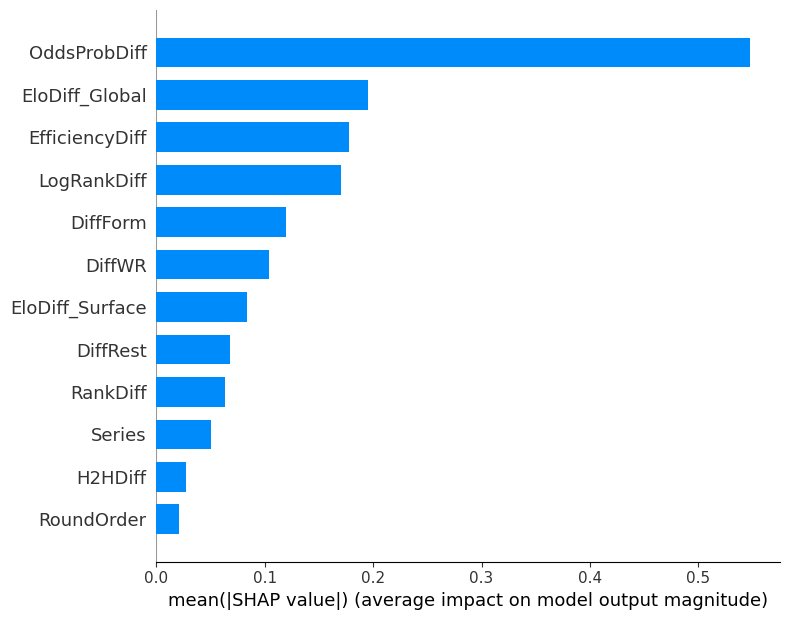

In [51]:
import shap

xgb_model = model.calibrated_classifiers_[0].estimator

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_sc)
shap.summary_plot(shap_values, X_train, plot_type="bar")


### 5.3. Segona ronda

Continuem el procés incremental afegint les dades de la primera ronda.

In [52]:
# Actualizar el conjunt de entrenament: afegir first_round al train actual
train_second_round = pd.concat([first_round, train], ignore_index=True)

print(f"Mida del train original: {len(train_second_round) - len(first_round)}")
print(f"Mida de first_round afegir: {len(first_round)}")
print(f"Mida del nou train: {len(train_second_round)}")
print(f"\nTrain actualizat correctament. Llest per la següent fase.")

train_second_round.head()


Mida del train original: 7607
Mida de first_round afegir: 64
Mida del nou train: 7671

Train actualizat correctament. Llest per la següent fase.


,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,CBW,CBL,GBW,GBL,IWW,IWL,SBW,SBL,B365W,B365L,B&WW,B&WL,EXW,EXL,PSW,PSL,WPts,LPts,UBW,UBL,LBW,LBL,SJW,SJL,MaxW,MaxL,AvgW,AvgL,BFEW,BFEL,MaxWin,MaxLoss,AvgWin,AvgLoss,PlayerA,PlayerB,RankA,RankB,RankDiff,WinnerBinary,MaxOddsPlayerA,MaxOddsPlayerB,AvgOddsPlayerA,AvgOddsPlayerB,H2H_A_wins,H2H_B_wins,H2H_Diff,WinsA,LossesA,WinsB,LossesB,WinRateA_cum,WinRateB_cum,Form10A,Form10B,RestDaysA,RestDaysB,DiffWR,DiffForm,DiffRest,LogRankDiff,H2HDiff,ProbA_odds,ProbB_odds,OddsProbDiff,WinRateA_x_Rank,WinRateB_x_Rank,EfficiencyDiff,EloA_Global,EloB_Global,EloA_Surface,EloB_Surface,EloDiff_Global,EloDiff_Surface,SurfaceText,RoundOrder
0,36,London,Wimbledon,2025-06-30,2,1,2,1st Round,5.0,Brooksby J.,Griekspoor T.,101.0,29.0,6.0,2.0,7.0,5.0,6.0,3.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.75,1.40,NaN,NaN,NaN,NaN,2.70,1.52,577.0,1755.0,NaN,NaN,NaN,NaN,NaN,NaN,2.85,1.53,2.75,1.44,NaN,NaN,2.75,1.52,2.725,1.46,Brooksby J.,Griekspoor T.,101.0,29.0,72.0,1,2.85,1.53,2.75,1.44,0,0,0,58,40,107,94,0.591837,0.532338,0.7,0.8,2,2,0.059498,-0.1,0,1.247825,0,0.350877,0.653595,-0.302718,0.005860,0.018356,-0.012497,1555.332933,1612.307681,1533.884576,1583.992935,-56.974748,-50.108359,Grass,1
1,36,London,Wimbledon,2025-06-30,2,1,2,1st Round,5.0,Bonzi B.,Medvedev D.,64.0,9.0,7.0,6.0,3.0,6.0,7.0,6.0,6.0,2.0,NaN,NaN,3.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.50,1.07,NaN,NaN,NaN,NaN,9.03,1.09,930.0,3420.0,NaN,NaN,NaN,NaN,NaN,NaN,12.50,1.09,8.56,1.07,NaN,NaN,9.03,1.09,8.765,1.08,Bonzi B.,Medvedev D.,64.0,9.0,55.0,1,12.50,1.09,8.56,1.07,1,0,1,51,68,377,160,0.428571,0.702048,0.2,0.6,6,8,-0.273477,-0.4,-2,1.961659,1,0.080000,0.917431,-0.837431,0.006696,0.078005,-0.071309,1445.016874,1704.547322,1426.887995,1659.093992,-259.530448,-232.205997,Grass,1
2,36,London,Wimbledon,2025-06-30,2,1,2,1st Round,5.0,Fonseca J.,Fearnley J.,54.0,51.0,6.0,4.0,6.0,1.0,7.0,6.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.50,2.63,NaN,NaN,NaN,NaN,1.49,2.79,1016.0,1060.0,NaN,NaN,NaN,NaN,NaN,NaN,1.53,2.86,1.47,2.67,NaN,NaN,1.50,2.79,1.495,2.71,Fearnley J.,Fonseca J.,51.0,54.0,-3.0,0,2.86,1.53,2.67,1.47,0,1,-1,15,14,18,16,0.517241,0.529412,0.5,0.4,5,4,-0.012170,0.1,1,-0.057158,-1,0.349650,0.653595,-0.303944,0.010142,0.009804,0.000338,1508.457531,1467.515774,1495.740663,1460.974829,40.941757,34.765834,Grass,1
3,36,London,Wimbledon,2025-06-30,2,1,2,1st Round,5.0,Khachanov K.,McDonald M.,20.0,88.0,7.0,5.0,6.0,4.0,6.0,4.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.22,4.33,NaN,NaN,NaN,NaN,1.21,4.91,2240.0,689.0,NaN,NaN,NaN,NaN,NaN,NaN,1.25,4.91,1.22,4.22,NaN,NaN,1.22,4.91,1.215,4.62,Khachanov K.,McDonald M.,20.0,88.0,-68.0,1,1.25,4.91,1.22,4.22,5,0,5,283,205,107,131,0.579918,0.449580,0.6,0.4,9,12,0.130338,0.2,-3,-1.481605,5,0.800000,0.203666,0.596334,0.028996,0.005109,0.023887,1582.443815,1518.933926,1548.116979,1490.150750,63.509889,57.966229,Grass,1
4,36,London,Wimbledon,2025-06-30,2,1,2,1st Round,5.0,Tiafoe F.,Moller E.,12.0,117.0,6.0,3.0,6.0,4.0,6.0,2.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.04,9.00,NaN,NaN,NaN,NaN,1.06,12.44,2990.0,499.0,NaN,NaN,NaN,NaN,NaN,NaN,1.07,13.50,1.05,10.57,NaN,NaN,1.06,12.44,1.050,10.72,Moller E.,Tiafoe F.,117.0,12.0,105.0,0,13.50,1.07,10.57,1.05,0,0,0,0,2,214,191,0.000000,0.528395,0.0,0.5,36,14,-0.528395,-0.5,22,2.277267,0,0.074074,0.934579,-0.860505,0.000000,0.044033,-0.044033,1499.250000,1562.354534,1498.500000,1528.328826,-63.104534,-29.828826,Grass,1


In [53]:
X_train = train_second_round[features].fillna(0)
X_test = second_round[features].fillna(0)
y_train = train_second_round['WinnerBinary']
y_test = second_round['WinnerBinary']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

base_model = XGBClassifier(
    n_estimators=500,                    # Nombre total d'arbres (boosting rounds) que es construiran. 500 és un valor força alt, bo per a un bon rendiment si es controla l'overfitting.
    max_depth=6,                         # Profunditat màxima de cada arbre. 6 és un valor moderat: permet interaccions complexes sense fer els arbres excessivament profunds.
    learning_rate=0.02,                  # Taxa d'aprenentatge (eta). 0.02 és bastant baixa → aprenentatge lent i estable, ideal quan tens molts estimators (500).
    subsample=0.85,                      # Percentatge de mostres (files) que s'utilitzen per entrenar cada arbre. 0.85 = 85% → ajuda a reduir overfitting i afegeix variància (com bagging).
    colsample_bytree=0.85,               # Percentatge de columnes (variables) que s'agafen aleatòriament per cada arbre. 85% → també redueix overfitting i millora la generalització.
    min_child_weight=5,                  # Suma mínima del pes Hessiana en un node fill. Valors >1 fan el model més conservador: evita dividir nodes amb poca informació.
    gamma=0.1,                           # Minimització mínima de la funció de pèrdua necessària per fer una partició addicional (regularització per poda). 0.1 afavoreix arbres més simples.
    reg_alpha=0.1,                       # Terme de regularització L1 sobre els pesos de les fulles. Ajuda a fer sparseness i és útil quan hi ha moltes variables irrellevants.
    reg_lambda=1.0,                      # Terme de regularització L2 (més suau que L1). 1.0 és el valor per defecte i sol funcionar bé en la majoria de casos.
    random_state=42,                     # Llavor per a la reproductibilitat dels resultats (aleatorietat controlada).
    n_jobs=-1,                           # Utilitza tots els nuclis disponibles del processador per entrenar en paral·lel → molt més ràpid.
    eval_metric='logloss'                # Mètrica d'avaluació durant l'entrenament (per classificació binària/multiclasse). 'logloss' = logarithmic loss (cross-entropy).
)

model = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
model.fit(X_train_sc, y_train)

pred = model.predict(X_test_sc)
prob = model.predict_proba(X_test_sc)[:, 1]
acc = accuracy_score(y_test, pred)
brier = brier_score_loss(y_test, prob)

print("\n" + "="*80)
print(f"ACCURACY FINAL TEST CRONOLÓGIC: {acc:.4f}")
print(f"Brier Score: {brier:.4f}")
print(classification_report(y_test, pred, digits=4))
print("="*80)



ACCURACY FINAL TEST CRONOLÓGIC: 0.6875
Brier Score: 0.2215
              precision    recall  f1-score   support

           0     0.5556    0.8333    0.6667        12
           1     0.8571    0.6000    0.7059        20

    accuracy                         0.6875        32
   macro avg     0.7063    0.7167    0.6863        32
weighted avg     0.7440    0.6875    0.6912        32



In [54]:
results_df, failed_df = analyze_predictions(
    df=second_round,
    y_true=second_round["WinnerBinary"].values,
    y_pred=pred,
    y_prob=prob,
    date_col="Date",
    player_a_col="PlayerA",
    player_b_col="PlayerB",
    true_col_name="WinnerBinary"
)


RESULTADOS DETALLADOS POR FILA:

Total de predicciones: 32
Correctas: 22 (68.75%)
Fallidas: 10 (31.25%)




,Date,PlayerA,PlayerB,WinnerBinary,Predicted,Probability,Result
7670,2025-07-02,Majchrzak K.,Quinn E.,1,0,0.480127,✗ Failed
7671,2025-07-02,Bellucci M.,Lehecka J.,1,0,0.080950,✗ Failed
7672,2025-07-02,Norrie C.,Tiafoe F.,1,0,0.449407,✗ Failed
7673,2025-07-02,Harris L.,Rublev A.,0,0,0.304263,✓ Correct
7674,2025-07-02,Alcaraz C.,Tarvet O.,1,1,0.747333,✓ Correct
7675,2025-07-02,Mannarino A.,Royer V.,1,1,0.730747,✓ Correct
7676,2025-07-02,Jarry N.,Tien L.,1,1,0.610303,✓ Correct
7677,2025-07-02,Khachanov K.,Mochizuki S.,1,1,0.907031,✓ Correct
7679,2025-07-02,Diallo G.,Fritz T.,0,0,0.221301,✓ Correct
7680,2025-07-02,Bonzi B.,Thompson J.,0,1,0.602943,✗ Failed



PREDICCIONES FALLIDAS:


,Date,PlayerA,PlayerB,WinnerBinary,Predicted,Probability
7670,2025-07-02,Majchrzak K.,Quinn E.,1,0,0.480127
7671,2025-07-02,Bellucci M.,Lehecka J.,1,0,0.080950
7672,2025-07-02,Norrie C.,Tiafoe F.,1,0,0.449407
7680,2025-07-02,Bonzi B.,Thompson J.,0,1,0.602943
7684,2025-07-03,Martinez P.,Navone M.,1,0,0.440453
7692,2025-07-03,Ofner S.,Paul T.,1,0,0.111165
7693,2025-07-03,Holmgren A.,Machac T.,1,0,0.310677
7697,2025-07-03,Auger-Aliassime F.,Struff J.L.,0,1,0.745062
7698,2025-07-03,Cilic M.,Draper J.,1,0,0.201223
7709,2025-07-04,Fucsovics M.,Monfils G.,1,0,0.490974


### 5.4. Tercera ronda

Continuem el procés incremental afegint les dades de la segona ronda.


In [55]:
# Actualizar el conjunto de entrenamiento: añadir second_round al train actual
train_third_round = pd.concat([second_round, train_second_round], ignore_index=True)

print(f"Tamaño del train original: {len(train_third_round) - len(second_round)}")
print(f"Tamaño de second_round añadido: {len(second_round)}")
print(f"Tamaño del nuevo train: {len(train_third_round)}")
print(f"\nTrain actualizado correctamente. Listo para la siguiente fase.")

train_third_round.head()


Tamaño del train original: 7671
Tamaño de second_round añadido: 32
Tamaño del nuevo train: 7703

Train actualizado correctamente. Listo para la siguiente fase.


,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,CBW,CBL,GBW,GBL,IWW,IWL,SBW,SBL,B365W,B365L,B&WW,B&WL,EXW,EXL,PSW,PSL,WPts,LPts,UBW,UBL,LBW,LBL,SJW,SJL,MaxW,MaxL,AvgW,AvgL,BFEW,BFEL,MaxWin,MaxLoss,AvgWin,AvgLoss,PlayerA,PlayerB,RankA,RankB,RankDiff,WinnerBinary,MaxOddsPlayerA,MaxOddsPlayerB,AvgOddsPlayerA,AvgOddsPlayerB,H2H_A_wins,H2H_B_wins,H2H_Diff,WinsA,LossesA,WinsB,LossesB,WinRateA_cum,WinRateB_cum,Form10A,Form10B,RestDaysA,RestDaysB,DiffWR,DiffForm,DiffRest,LogRankDiff,H2HDiff,ProbA_odds,ProbB_odds,OddsProbDiff,WinRateA_x_Rank,WinRateB_x_Rank,EfficiencyDiff,EloA_Global,EloB_Global,EloA_Surface,EloB_Surface,EloDiff_Global,EloDiff_Surface,SurfaceText,RoundOrder
0,36,London,Wimbledon,2025-07-02,2,1,2,2nd Round,5.0,Majchrzak K.,Quinn E.,109.0,89.0,6.0,1.0,6.0,4.0,6.0,3.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.20,1.62,NaN,NaN,NaN,NaN,2.26,1.72,527.0,682.0,NaN,NaN,NaN,NaN,NaN,NaN,2.30,1.75,2.16,1.69,NaN,NaN,2.26,1.72,2.230,1.670,Majchrzak K.,Quinn E.,109.0,89.0,20.0,1,2.30,1.75,2.16,1.69,0,0,0,23,35,9,16,0.396552,0.360000,0.5,0.4,2,2,0.036552,0.1,0,0.202712,0,0.434783,0.571429,-0.136646,0.003638,0.004045,-0.000407,1471.900657,1523.756610,1458.919230,1515.198809,-51.855952,-56.279580,Grass,2
1,36,London,Wimbledon,2025-07-02,2,1,2,2nd Round,5.0,Bellucci M.,Lehecka J.,73.0,25.0,7.0,6.0,6.0,1.0,7.0,5.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.50,1.20,NaN,NaN,NaN,NaN,5.04,1.21,864.0,1965.0,NaN,NaN,NaN,NaN,NaN,NaN,5.30,1.22,4.57,1.20,NaN,NaN,5.04,1.21,4.770,1.205,Bellucci M.,Lehecka J.,73.0,25.0,48.0,1,5.30,1.22,4.57,1.20,0,0,0,14,19,90,68,0.424242,0.569620,0.4,0.7,2,2,-0.145378,-0.3,0,1.071584,0,0.188679,0.819672,-0.630993,0.005812,0.022785,-0.016973,1489.768419,1617.356344,1482.981179,1595.193619,-127.587925,-112.212440,Grass,2
2,36,London,Wimbledon,2025-07-02,2,1,2,2nd Round,5.0,Norrie C.,Tiafoe F.,61.0,12.0,4.0,6.0,6.0,4.0,6.0,3.0,7.0,5.0,NaN,NaN,3.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.50,1.53,NaN,NaN,NaN,NaN,2.59,1.57,952.0,2990.0,NaN,NaN,NaN,NaN,NaN,NaN,2.66,1.59,2.48,1.54,NaN,NaN,2.59,1.57,2.545,1.550,Norrie C.,Tiafoe F.,61.0,12.0,49.0,1,2.66,1.59,2.48,1.54,1,2,-1,213,156,215,191,0.577236,0.529557,0.6,0.6,2,2,0.047679,0.0,0,1.625967,-1,0.375940,0.628931,-0.252991,0.009463,0.044130,-0.034667,1567.665112,1578.627935,1532.492388,1545.800085,-10.962824,-13.307697,Grass,2
3,36,London,Wimbledon,2025-07-02,2,1,2,2nd Round,5.0,Rublev A.,Harris L.,14.0,320.0,6.0,7.0,6.0,4.0,7.0,6.0,6.0,3.0,NaN,NaN,3.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.29,3.75,NaN,NaN,NaN,NaN,1.31,3.81,2920.0,159.0,NaN,NaN,NaN,NaN,NaN,NaN,1.33,3.90,1.29,3.60,NaN,NaN,1.31,3.81,1.300,3.780,Harris L.,Rublev A.,320.0,14.0,306.0,0,3.90,1.33,3.60,1.29,0,3,-3,63,77,335,188,0.450000,0.640535,0.4,0.7,2,2,-0.190535,-0.3,0,3.129264,-3,0.256410,0.751880,-0.495469,0.001406,0.045753,-0.044346,1487.628773,1623.169013,1468.161856,1590.407235,-135.540240,-122.245379,Grass,2
4,36,London,Wimbledon,2025-07-02,2,1,2,2nd Round,5.0,Alcaraz C.,Tarvet O.,2.0,733.0,6.0,1.0,6.0,4.0,6.0,4.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.01,12.00,NaN,NaN,NaN,NaN,NaN,NaN,9300.0,36.0,NaN,NaN,NaN,NaN,NaN,NaN,1.03,34.00,1.01,19.33,NaN,NaN,1.01,12.00,1.010,12.000,Alcaraz C.,Tarvet O.,2.0,733.0,-731.0,1,1.03,34.00,1.01,19.33,0,0,0,235,59,1,0,0.799320,1.000000,1.0,1.0,2,2,-0.200680,0.0,0,-5.903999,0,0.970874,0.029412,0.941462,0.399660,0.001364,0.398296,1806.381603,1524.487375,1767.802433,1522.975500,281.894228,244.826933,Grass,2


In [56]:
X_train = train_third_round[features].fillna(0)
X_test = third_round[features].fillna(0)
y_train = train_third_round['WinnerBinary']
y_test = third_round['WinnerBinary']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

base_model = XGBClassifier(
    n_estimators=500,                    # Nombre total d'arbres (boosting rounds) que es construiran. 500 és un valor força alt, bo per a un bon rendiment si es controla l'overfitting.
    max_depth=6,                         # Profunditat màxima de cada arbre. 6 és un valor moderat: permet interaccions complexes sense fer els arbres excessivament profunds.
    learning_rate=0.02,                  # Taxa d'aprenentatge (eta). 0.02 és bastant baixa → aprenentatge lent i estable, ideal quan tens molts estimators (500).
    subsample=0.85,                      # Percentatge de mostres (files) que s'utilitzen per entrenar cada arbre. 0.85 = 85% → ajuda a reduir overfitting i afegeix variància (com bagging).
    colsample_bytree=0.85,               # Percentatge de columnes (variables) que s'agafen aleatòriament per cada arbre. 85% → també redueix overfitting i millora la generalització.
    min_child_weight=5,                  # Suma mínima del pes Hessiana en un node fill. Valors >1 fan el model més conservador: evita dividir nodes amb poca informació.
    gamma=0.1,                           # Minimització mínima de la funció de pèrdua necessària per fer una partició addicional (regularització per poda). 0.1 afavoreix arbres més simples.
    reg_alpha=0.1,                       # Terme de regularització L1 sobre els pesos de les fulles. Ajuda a fer sparseness i és útil quan hi ha moltes variables irrellevants.
    reg_lambda=1.0,                      # Terme de regularització L2 (més suau que L1). 1.0 és el valor per defecte i sol funcionar bé en la majoria de casos.
    random_state=42,                     # Llavor per a la reproductibilitat dels resultats (aleatorietat controlada).
    n_jobs=-1,                           # Utilitza tots els nuclis disponibles del processador per entrenar en paral·lel → molt més ràpid.
    eval_metric='logloss'                # Mètrica d'avaluació durant l'entrenament (per classificació binària/multiclasse). 'logloss' = logarithmic loss (cross-entropy).
)

model = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
model.fit(X_train_sc, y_train)

pred = model.predict(X_test_sc)
prob = model.predict_proba(X_test_sc)[:, 1]
acc = accuracy_score(y_test, pred)
brier = brier_score_loss(y_test, prob)

print("\n" + "="*80)
print(f"ACCURACY FINAL TEST CRONOLÓGIC: {acc:.4f}")
print(f"Brier Score: {brier:.4f}")
print(classification_report(y_test, pred, digits=4))
print("="*80)



ACCURACY FINAL TEST CRONOLÓGIC: 0.7500
Brier Score: 0.1622
              precision    recall  f1-score   support

           0     0.7778    0.7778    0.7778         9
           1     0.7143    0.7143    0.7143         7

    accuracy                         0.7500        16
   macro avg     0.7460    0.7460    0.7460        16
weighted avg     0.7500    0.7500    0.7500        16



In [57]:
results_df, failed_df = analyze_predictions(
    df=third_round,
    y_true=third_round["WinnerBinary"].values,
    y_pred=pred,
    y_prob=prob,
    date_col="Date",
    player_a_col="PlayerA",
    player_b_col="PlayerB",
    true_col_name="WinnerBinary"
)


RESULTADOS DETALLADOS POR FILA:

Total de predicciones: 16
Correctas: 12 (75.00%)
Fallidas: 4 (25.00%)




,Date,PlayerA,PlayerB,WinnerBinary,Predicted,Probability,Result
7701,2025-07-04,Mannarino A.,Rublev A.,0,0,0.367198,✓ Correct
7702,2025-07-04,Bellucci M.,Norrie C.,0,0,0.339669,✓ Correct
7703,2025-07-04,Alcaraz C.,Struff J.L.,1,1,0.959540,✓ Correct
7704,2025-07-04,Fonseca J.,Jarry N.,0,1,0.731875,✗ Failed
7705,2025-07-04,Davidovich Fokina A.,Fritz T.,0,0,0.283447,✓ Correct
7706,2025-07-04,Majchrzak K.,Rinderknech A.,1,0,0.450084,✗ Failed
7707,2025-07-04,Borges N.,Khachanov K.,0,0,0.383130,✓ Correct
7710,2025-07-04,Darderi L.,Thompson J.,0,0,0.413770,✓ Correct
7711,2025-07-05,Cobolli F.,Mensik J.,1,0,0.356637,✗ Failed
7712,2025-07-05,Nakashima B.,Sonego L.,0,1,0.655420,✗ Failed



PREDICCIONES FALLIDAS:


,Date,PlayerA,PlayerB,WinnerBinary,Predicted,Probability
7704,2025-07-04,Fonseca J.,Jarry N.,0,1,0.731875
7706,2025-07-04,Majchrzak K.,Rinderknech A.,1,0,0.450084
7711,2025-07-05,Cobolli F.,Mensik J.,1,0,0.356637
7712,2025-07-05,Nakashima B.,Sonego L.,0,1,0.655420


### 5.5. Quarta ronda


In [58]:
# Actualizar el conjunto de entrenamiento: añadir third_round al train actual
train_fourth_round = pd.concat([third_round, train_third_round], ignore_index=True)

print(f"Tamaño del train original: {len(train_fourth_round) - len(third_round)}")
print(f"Tamaño de third_round añadido: {len(third_round)}")
print(f"Tamaño del nuevo train: {len(train_fourth_round)}")
print(f"\nTrain actualizado correctamente. Listo para la siguiente fase.")

train_fourth_round.head()


Tamaño del train original: 7703
Tamaño de third_round añadido: 16
Tamaño del nuevo train: 7719

Train actualizado correctamente. Listo para la siguiente fase.


,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,CBW,CBL,GBW,GBL,IWW,IWL,SBW,SBL,B365W,B365L,B&WW,B&WL,EXW,EXL,PSW,PSL,WPts,LPts,UBW,UBL,LBW,LBL,SJW,SJL,MaxW,MaxL,AvgW,AvgL,BFEW,BFEL,MaxWin,MaxLoss,AvgWin,AvgLoss,PlayerA,PlayerB,RankA,RankB,RankDiff,WinnerBinary,MaxOddsPlayerA,MaxOddsPlayerB,AvgOddsPlayerA,AvgOddsPlayerB,H2H_A_wins,H2H_B_wins,H2H_Diff,WinsA,LossesA,WinsB,LossesB,WinRateA_cum,WinRateB_cum,Form10A,Form10B,RestDaysA,RestDaysB,DiffWR,DiffForm,DiffRest,LogRankDiff,H2HDiff,ProbA_odds,ProbB_odds,OddsProbDiff,WinRateA_x_Rank,WinRateB_x_Rank,EfficiencyDiff,EloA_Global,EloB_Global,EloA_Surface,EloB_Surface,EloDiff_Global,EloDiff_Surface,SurfaceText,RoundOrder
0,36,London,Wimbledon,2025-07-04,2,1,2,3rd Round,5.0,Rublev A.,Mannarino A.,14.0,123.0,7.0,5.0,6.0,2.0,6.0,3.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.25,3.75,NaN,NaN,NaN,NaN,1.30,3.96,2920.0,477.0,NaN,NaN,NaN,NaN,NaN,NaN,1.31,4.10,1.27,3.77,NaN,NaN,1.30,3.96,1.275,3.855,Mannarino A.,Rublev A.,123.0,14.0,109.0,0,4.10,1.31,3.77,1.27,1,3,-2,298,344,336,188,0.464174,0.641221,0.4,0.7,2,2,-0.177047,-0.3,0,2.173127,-2,0.243902,0.763359,-0.519456,0.003774,0.045802,-0.042028,1584.607625,1632.157744,1542.463192,1599.133457,-47.550119,-56.670265,Grass,3
1,36,London,Wimbledon,2025-07-04,2,1,2,3rd Round,5.0,Norrie C.,Bellucci M.,61.0,73.0,7.0,6.0,6.0,4.0,6.0,3.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.57,2.30,NaN,NaN,NaN,NaN,1.60,2.50,952.0,864.0,NaN,NaN,NaN,NaN,NaN,NaN,1.63,2.56,1.56,2.41,NaN,NaN,1.60,2.50,1.585,2.400,Bellucci M.,Norrie C.,73.0,61.0,12.0,0,2.56,1.63,2.41,1.56,0,0,0,15,19,214,156,0.441176,0.578378,0.4,0.6,2,2,-0.137202,-0.2,0,0.179586,0,0.390625,0.613497,-0.222872,0.006044,0.009482,-0.003438,1510.097396,1593.687989,1501.947938,1557.928281,-83.590593,-55.980344,Grass,3
2,36,London,Wimbledon,2025-07-04,2,1,2,3rd Round,5.0,Alcaraz C.,Struff J.L.,2.0,125.0,6.0,1.0,3.0,6.0,6.0,3.0,6.0,4.0,NaN,NaN,3.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.04,11.00,NaN,NaN,NaN,NaN,1.05,15.53,9300.0,475.0,NaN,NaN,NaN,NaN,NaN,NaN,1.05,18.00,1.03,12.61,NaN,NaN,1.05,15.53,1.045,13.265,Alcaraz C.,Struff J.L.,2.0,125.0,-123.0,1,1.05,18.00,1.03,12.61,3,1,2,236,59,208,241,0.800000,0.463252,1.0,0.4,2,1,0.336748,0.6,1,-4.135167,2,0.952381,0.055556,0.896825,0.400000,0.003706,0.396294,1808.905182,1557.455951,1770.114390,1525.673558,251.449231,244.440832,Grass,3
3,36,London,Wimbledon,2025-07-04,2,1,2,3rd Round,5.0,Jarry N.,Fonseca J.,143.0,54.0,6.0,3.0,6.0,4.0,3.0,6.0,7.0,6.0,NaN,NaN,3.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.90,1.40,NaN,NaN,NaN,NaN,3.05,1.43,418.0,1016.0,NaN,NaN,NaN,NaN,NaN,NaN,3.05,1.48,2.81,1.42,NaN,NaN,3.05,1.43,2.975,1.415,Fonseca J.,Jarry N.,54.0,143.0,-89.0,0,1.48,3.05,1.42,2.81,0,0,0,20,16,107,110,0.555556,0.493088,0.5,0.5,2,2,0.062468,0.0,0,-0.973861,0,0.675676,0.327869,0.347807,0.010288,0.003448,0.006840,1508.754340,1533.371476,1499.726319,1509.966528,-24.617136,-10.240208,Grass,3
4,36,London,Wimbledon,2025-07-04,2,1,2,3rd Round,5.0,Fritz T.,Davidovich Fokina A.,5.0,27.0,6.0,4.0,6.0,3.0,6.0,7.0,6.0,1.0,NaN,NaN,3.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.25,3.75,NaN,NaN,NaN,NaN,1.30,3.92,4635.0,1845.0,NaN,NaN,NaN,NaN,NaN,NaN,1.34,3.92,1.28,3.66,NaN,NaN,1.30,3.92,1.275,3.835,Davidovich Fokina A.,Fritz T.,27.0,5.0,22.0,0,3.92,1.34,3.66,1.28,3,2,1,138,127,286,189,0.520755,0.602105,0.7,0.9,1,2,-0.081351,-0.2,-1,1.686399,1,0.255102,0.746269,-0.491167,0.019287,0.120421,-0.101134,1528.970909,1707.759945,1509.092212,1668.348596,-178.789036,-159.256383,Grass,3


In [59]:
X_train = train_fourth_round[features].fillna(0)
X_test = fourth_round[features].fillna(0)
y_train = train_fourth_round['WinnerBinary']
y_test = fourth_round['WinnerBinary']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

base_model = XGBClassifier(
    n_estimators=500,                    # Nombre total d'arbres (boosting rounds) que es construiran. 500 és un valor força alt, bo per a un bon rendiment si es controla l'overfitting.
    max_depth=6,                         # Profunditat màxima de cada arbre. 6 és un valor moderat: permet interaccions complexes sense fer els arbres excessivament profunds.
    learning_rate=0.02,                  # Taxa d'aprenentatge (eta). 0.02 és bastant baixa → aprenentatge lent i estable, ideal quan tens molts estimators (500).
    subsample=0.85,                      # Percentatge de mostres (files) que s'utilitzen per entrenar cada arbre. 0.85 = 85% → ajuda a reduir overfitting i afegeix variància (com bagging).
    colsample_bytree=0.85,               # Percentatge de columnes (variables) que s'agafen aleatòriament per cada arbre. 85% → també redueix overfitting i millora la generalització.
    min_child_weight=5,                  # Suma mínima del pes Hessiana en un node fill. Valors >1 fan el model més conservador: evita dividir nodes amb poca informació.
    gamma=0.1,                           # Minimització mínima de la funció de pèrdua necessària per fer una partició addicional (regularització per poda). 0.1 afavoreix arbres més simples.
    reg_alpha=0.1,                       # Terme de regularització L1 sobre els pesos de les fulles. Ajuda a fer sparseness i és útil quan hi ha moltes variables irrellevants.
    reg_lambda=1.0,                      # Terme de regularització L2 (més suau que L1). 1.0 és el valor per defecte i sol funcionar bé en la majoria de casos.
    random_state=42,                     # Llavor per a la reproductibilitat dels resultats (aleatorietat controlada).
    n_jobs=-1,                           # Utilitza tots els nuclis disponibles del processador per entrenar en paral·lel → molt més ràpid.
    eval_metric='logloss'                # Mètrica d'avaluació durant l'entrenament (per classificació binària/multiclasse). 'logloss' = logarithmic loss (cross-entropy).
)

model = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
model.fit(X_train_sc, y_train)

pred = model.predict(X_test_sc)
prob = model.predict_proba(X_test_sc)[:, 1]
acc = accuracy_score(y_test, pred)
brier = brier_score_loss(y_test, prob)

print("\n" + "="*80)
print(f"ACCURACY FINAL TEST CRONOLÓGIC: {acc:.4f}")
print(f"Brier Score: {brier:.4f}")
print(classification_report(y_test, pred, digits=4))
print("="*80)



ACCURACY FINAL TEST CRONOLÓGIC: 0.8750
Brier Score: 0.1277
              precision    recall  f1-score   support

           0     1.0000    0.7500    0.8571         4
           1     0.8000    1.0000    0.8889         4

    accuracy                         0.8750         8
   macro avg     0.9000    0.8750    0.8730         8
weighted avg     0.9000    0.8750    0.8730         8



In [60]:
results_df, failed_df = analyze_predictions(
    df=fourth_round,
    y_true=fourth_round["WinnerBinary"].values,
    y_pred=pred,
    y_prob=prob,
    date_col="Date",
    player_a_col="PlayerA",
    player_b_col="PlayerB",
    true_col_name="WinnerBinary"
)


RESULTADOS DETALLADOS POR FILA:

Total de predicciones: 8
Correctas: 7 (87.50%)
Fallidas: 1 (12.50%)




,Date,PlayerA,PlayerB,WinnerBinary,Predicted,Probability,Result
7719,2025-07-06,Fritz T.,Thompson J.,1,1,0.946447,✓ Correct
7720,2025-07-06,Jarry N.,Norrie C.,0,0,0.474959,✓ Correct
7721,2025-07-06,Khachanov K.,Majchrzak K.,1,1,0.652003,✓ Correct
7722,2025-07-06,Alcaraz C.,Rublev A.,1,1,0.989474,✓ Correct
7723,2025-07-07,Cilic M.,Cobolli F.,0,1,0.669219,✗ Failed
7724,2025-07-07,Shelton B.,Sonego L.,1,1,0.625515,✓ Correct
7725,2025-07-07,Dimitrov G.,Sinner J.,0,0,0.071516,✓ Correct
7726,2025-07-07,De Minaur A.,Djokovic N.,0,0,0.281280,✓ Correct



PREDICCIONES FALLIDAS:


,Date,PlayerA,PlayerB,WinnerBinary,Predicted,Probability
7723,2025-07-07,Cilic M.,Cobolli F.,0,1,0.669219


### 5.6. Quarts de final


In [61]:
# Actualizar el conjunto de entrenamiento: añadir fourth_round al train actual
train_quarter_finals = pd.concat([fourth_round, train_fourth_round], ignore_index=True)

print(f"Tamaño del train original: {len(train_quarter_finals) - len(fourth_round)}")
print(f"Tamaño de fourth_round añadido: {len(fourth_round)}")
print(f"Tamaño del nuevo train: {len(train_quarter_finals)}")
print(f"\nTrain actualizado correctamente. Listo para la siguiente fase.")

train_quarter_finals.head()


Tamaño del train original: 7719
Tamaño de fourth_round añadido: 8
Tamaño del nuevo train: 7727

Train actualizado correctamente. Listo para la siguiente fase.


,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,CBW,CBL,GBW,GBL,IWW,IWL,SBW,SBL,B365W,B365L,B&WW,B&WL,EXW,EXL,PSW,PSL,WPts,LPts,UBW,UBL,LBW,LBL,SJW,SJL,MaxW,MaxL,AvgW,AvgL,BFEW,BFEL,MaxWin,MaxLoss,AvgWin,AvgLoss,PlayerA,PlayerB,RankA,RankB,RankDiff,WinnerBinary,MaxOddsPlayerA,MaxOddsPlayerB,AvgOddsPlayerA,AvgOddsPlayerB,H2H_A_wins,H2H_B_wins,H2H_Diff,WinsA,LossesA,WinsB,LossesB,WinRateA_cum,WinRateB_cum,Form10A,Form10B,RestDaysA,RestDaysB,DiffWR,DiffForm,DiffRest,LogRankDiff,H2HDiff,ProbA_odds,ProbB_odds,OddsProbDiff,WinRateA_x_Rank,WinRateB_x_Rank,EfficiencyDiff,EloA_Global,EloB_Global,EloA_Surface,EloB_Surface,EloDiff_Global,EloDiff_Surface,SurfaceText,RoundOrder
0,36,London,Wimbledon,2025-07-06,2,1,2,4th Round,5.0,Fritz T.,Thompson J.,5.0,44.0,6.0,1.0,3.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,Retired,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.14,5.50,NaN,NaN,NaN,NaN,1.15,6.36,4635.0,1200.0,NaN,NaN,NaN,NaN,NaN,NaN,1.16,6.80,1.14,5.64,NaN,NaN,1.15,6.36,1.145,5.930,Fritz T.,Thompson J.,5.0,44.0,-39.0,1,1.16,6.80,1.14,5.64,1,1,0,287,189,147,165,0.602941,0.471154,0.9,0.5,2,2,0.131787,0.4,0,-2.174752,0,0.862069,0.147059,0.715010,0.120588,0.010708,0.109880,1712.378734,1588.874387,1672.615199,1554.619894,123.504347,117.995306,Grass,4
1,36,London,Wimbledon,2025-07-06,2,1,2,4th Round,5.0,Norrie C.,Jarry N.,61.0,143.0,6.0,3.0,7.0,6.0,6.0,7.0,6.0,7.0,6.0,3.0,3.0,2.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.83,1.91,NaN,NaN,NaN,NaN,1.87,2.04,952.0,418.0,NaN,NaN,NaN,NaN,NaN,NaN,2.10,2.08,1.84,1.96,NaN,NaN,1.87,2.04,1.850,1.975,Jarry N.,Norrie C.,143.0,61.0,82.0,0,2.08,2.10,1.96,1.84,1,0,1,108,110,215,156,0.495413,0.579515,0.5,0.6,2,2,-0.084102,-0.1,0,0.851971,1,0.480769,0.476190,0.004579,0.003464,0.009500,-0.006036,1556.753588,1604.802715,1533.665233,1569.465233,-48.049127,-35.800000,Grass,4
2,36,London,Wimbledon,2025-07-06,2,1,2,4th Round,5.0,Khachanov K.,Majchrzak K.,20.0,109.0,6.0,4.0,6.0,2.0,6.0,3.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.36,3.20,NaN,NaN,NaN,NaN,1.38,3.36,2240.0,527.0,NaN,NaN,NaN,NaN,NaN,NaN,1.40,3.40,1.35,3.19,NaN,NaN,1.38,3.36,1.370,3.280,Khachanov K.,Majchrzak K.,20.0,109.0,-89.0,1,1.40,3.40,1.35,3.19,3,0,3,286,205,25,35,0.582485,0.416667,0.7,0.6,2,2,0.165818,0.1,0,-1.695616,3,0.714286,0.294118,0.420168,0.029124,0.003823,0.025302,1616.322216,1520.374896,1581.881337,1505.298845,95.947320,76.582492,Grass,4
3,36,London,Wimbledon,2025-07-06,2,1,2,4th Round,5.0,Alcaraz C.,Rublev A.,2.0,14.0,6.0,7.0,6.0,3.0,6.0,4.0,6.0,4.0,NaN,NaN,3.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.08,7.00,NaN,NaN,NaN,NaN,1.10,8.57,9300.0,2920.0,NaN,NaN,NaN,NaN,NaN,NaN,1.11,9.40,1.09,7.50,NaN,NaN,1.10,8.57,1.090,7.785,Alcaraz C.,Rublev A.,2.0,14.0,-12.0,1,1.11,9.40,1.09,7.50,2,1,1,237,59,337,188,0.800676,0.641905,1.0,0.7,2,2,0.158771,0.3,0,-1.945910,1,0.900901,0.106383,0.794518,0.400338,0.045850,0.354487,1811.958925,1649.303628,1772.431327,1614.953967,162.655297,157.477361,Grass,4
4,36,London,Wimbledon,2025-07-07,2,1,2,4th Round,5.0,Cobolli F.,Cilic M.,24.0,83.0,6.0,4.0,6.0,4.0,6.0,7.0,7.0,6.0,NaN,NaN,3.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.83,2.00,NaN,NaN,NaN,NaN,1.88,2.03,2035.0,722.0,NaN,NaN,NaN,NaN,NaN,NaN,1.89,2.10,1.79,2.01,NaN,NaN,1.88,2.03,1.855,2.015,Cilic M.,Cobolli F.,83.0,24.0,59.0,0,2.10,1.89,2.01,1.79,0,2,-2,556,323,58,49,0.632537,0.542056,0.5,0.7,2,2,0.090481,-0.2,0,1.240787,-2,0.476190,0.529101,-0.052910,0.007621,0.022586,-0.014965,1767.584060,1570.980643,1705.444237,1556.305961,196.603417,149.138276,Grass,4


In [62]:
X_train = train_quarter_finals[features].fillna(0)
X_test = quarter_finals[features].fillna(0)
y_train = train_quarter_finals['WinnerBinary']
y_test = quarter_finals['WinnerBinary']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

base_model = XGBClassifier(
    n_estimators=500,                    # Nombre total d'arbres (boosting rounds) que es construiran. 500 és un valor força alt, bo per a un bon rendiment si es controla l'overfitting.
    max_depth=6,                         # Profunditat màxima de cada arbre. 6 és un valor moderat: permet interaccions complexes sense fer els arbres excessivament profunds.
    learning_rate=0.02,                  # Taxa d'aprenentatge (eta). 0.02 és bastant baixa → aprenentatge lent i estable, ideal quan tens molts estimators (500).
    subsample=0.85,                      # Percentatge de mostres (files) que s'utilitzen per entrenar cada arbre. 0.85 = 85% → ajuda a reduir overfitting i afegeix variància (com bagging).
    colsample_bytree=0.85,               # Percentatge de columnes (variables) que s'agafen aleatòriament per cada arbre. 85% → també redueix overfitting i millora la generalització.
    min_child_weight=5,                  # Suma mínima del pes Hessiana en un node fill. Valors >1 fan el model més conservador: evita dividir nodes amb poca informació.
    gamma=0.1,                           # Minimització mínima de la funció de pèrdua necessària per fer una partició addicional (regularització per poda). 0.1 afavoreix arbres més simples.
    reg_alpha=0.1,                       # Terme de regularització L1 sobre els pesos de les fulles. Ajuda a fer sparseness i és útil quan hi ha moltes variables irrellevants.
    reg_lambda=1.0,                      # Terme de regularització L2 (més suau que L1). 1.0 és el valor per defecte i sol funcionar bé en la majoria de casos.
    random_state=42,                     # Llavor per a la reproductibilitat dels resultats (aleatorietat controlada).
    n_jobs=-1,                           # Utilitza tots els nuclis disponibles del processador per entrenar en paral·lel → molt més ràpid.
    eval_metric='logloss'                # Mètrica d'avaluació durant l'entrenament (per classificació binària/multiclasse). 'logloss' = logarithmic loss (cross-entropy).
)

model = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
model.fit(X_train_sc, y_train)

pred = model.predict(X_test_sc)
prob = model.predict_proba(X_test_sc)[:, 1]
acc = accuracy_score(y_test, pred)
brier = brier_score_loss(y_test, prob)

print("\n" + "="*80)
print(f"ACCURACY FINAL TEST CRONOLÓGIC: {acc:.4f}")
print(f"Brier Score: {brier:.4f}")
print(classification_report(y_test, pred, digits=4))
print("="*80)



ACCURACY FINAL TEST CRONOLÓGIC: 1.0000
Brier Score: 0.0383
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         2
           1     1.0000    1.0000    1.0000         2

    accuracy                         1.0000         4
   macro avg     1.0000    1.0000    1.0000         4
weighted avg     1.0000    1.0000    1.0000         4



In [63]:
results_df, failed_df = analyze_predictions(
    df=quarter_finals,
    y_true=quarter_finals["WinnerBinary"].values,
    y_pred=pred,
    y_prob=prob,
    date_col="Date",
    player_a_col="PlayerA",
    player_b_col="PlayerB",
    true_col_name="WinnerBinary"
)


RESULTADOS DETALLADOS POR FILA:

Total de predicciones: 4
Correctas: 4 (100.00%)
Fallidas: 0 (0.00%)




,Date,PlayerA,PlayerB,WinnerBinary,Predicted,Probability,Result
7727,2025-07-08,Alcaraz C.,Norrie C.,1,1,0.945621,✓ Correct
7728,2025-07-08,Fritz T.,Khachanov K.,1,1,0.734599,✓ Correct
7729,2025-07-09,Cobolli F.,Djokovic N.,0,0,0.156263,✓ Correct
7730,2025-07-09,Shelton B.,Sinner J.,0,0,0.235493,✓ Correct



PREDICCIONES FALLIDAS:
¡Todas las predicciones han sido correctas!


### 5.7. Semifinals


In [64]:
# Actualizar el conjunto de entrenamiento: añadir quarter_finals al train actual
train_semi_finals = pd.concat([quarter_finals, train_quarter_finals], ignore_index=True)

print(f"Tamaño del train original: {len(train_semi_finals) - len(quarter_finals)}")
print(f"Tamaño de quarter_finals añadido: {len(quarter_finals)}")
print(f"Tamaño del nuevo train: {len(train_semi_finals)}")
print(f"\nTrain actualizado correctamente. Listo para la siguiente fase.")

train_semi_finals.head()


Tamaño del train original: 7727
Tamaño de quarter_finals añadido: 4
Tamaño del nuevo train: 7731

Train actualizado correctamente. Listo para la siguiente fase.


,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,CBW,CBL,GBW,GBL,IWW,IWL,SBW,SBL,B365W,B365L,B&WW,B&WL,EXW,EXL,PSW,PSL,WPts,LPts,UBW,UBL,LBW,LBL,SJW,SJL,MaxW,MaxL,AvgW,AvgL,BFEW,BFEL,MaxWin,MaxLoss,AvgWin,AvgLoss,PlayerA,PlayerB,RankA,RankB,RankDiff,WinnerBinary,MaxOddsPlayerA,MaxOddsPlayerB,AvgOddsPlayerA,AvgOddsPlayerB,H2H_A_wins,H2H_B_wins,H2H_Diff,WinsA,LossesA,WinsB,LossesB,WinRateA_cum,WinRateB_cum,Form10A,Form10B,RestDaysA,RestDaysB,DiffWR,DiffForm,DiffRest,LogRankDiff,H2HDiff,ProbA_odds,ProbB_odds,OddsProbDiff,WinRateA_x_Rank,WinRateB_x_Rank,EfficiencyDiff,EloA_Global,EloB_Global,EloA_Surface,EloB_Surface,EloDiff_Global,EloDiff_Surface,SurfaceText,RoundOrder
0,36,London,Wimbledon,2025-07-08,2,1,2,Quarterfinals,5.0,Alcaraz C.,Norrie C.,2.0,61.0,6.0,2.0,6.0,3.0,6.0,3.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.06,9.00,NaN,NaN,NaN,NaN,1.07,10.89,9300.0,952.0,NaN,NaN,NaN,NaN,NaN,NaN,1.07,13.5,1.05,9.96,NaN,NaN,1.07,10.89,1.065,9.945,Alcaraz C.,Norrie C.,2.0,61.0,-59.0,1,1.07,13.50,1.05,9.96,4,2,2,238,59,216,156,0.801347,0.580645,1.0,0.7,2,2,0.220702,0.3,0,-3.417727,2,0.934579,0.074074,0.860505,0.400673,0.009519,0.391155,1816.908221,1621.932975,1776.637363,1586.541410,194.975246,190.095953,Grass,6
1,36,London,Wimbledon,2025-07-08,2,1,2,Quarterfinals,5.0,Fritz T.,Khachanov K.,5.0,20.0,6.0,3.0,6.0,4.0,1.0,6.0,7.0,6.0,NaN,NaN,3.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.29,3.75,NaN,NaN,NaN,NaN,1.29,4.06,4635.0,2240.0,NaN,NaN,NaN,NaN,NaN,NaN,1.31,4.2,1.27,3.76,NaN,NaN,1.29,4.06,1.290,3.905,Fritz T.,Khachanov K.,5.0,20.0,-15.0,1,1.31,4.20,1.27,3.76,0,1,-1,288,189,287,205,0.603774,0.583333,0.9,0.8,2,2,0.020440,0.1,0,-1.386294,-1,0.763359,0.238095,0.525264,0.120755,0.029167,0.091588,1721.794354,1626.906557,1681.428764,1592.503282,94.887798,88.925482,Grass,6
2,36,London,Wimbledon,2025-07-09,2,1,2,Quarterfinals,5.0,Djokovic N.,Cobolli F.,6.0,24.0,6.0,7.0,6.0,2.0,7.0,5.0,6.0,4.0,NaN,NaN,3.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.10,7.00,NaN,NaN,NaN,NaN,1.11,8.33,4630.0,2035.0,NaN,NaN,NaN,NaN,NaN,NaN,1.12,8.6,1.09,7.53,NaN,NaN,1.11,8.33,1.105,7.665,Cobolli F.,Djokovic N.,24.0,6.0,18.0,0,8.60,1.12,7.53,1.09,0,1,-1,59,49,1093,215,0.546296,0.835627,0.7,0.9,2,2,-0.289331,-0.2,0,1.386294,-1,0.116279,0.892857,-0.776578,0.022762,0.139271,-0.116509,1585.915415,1939.233116,1569.343906,1860.199075,-353.317701,-290.855169,Grass,6
3,36,London,Wimbledon,2025-07-09,2,1,2,Quarterfinals,5.0,Sinner J.,Shelton B.,1.0,10.0,7.0,6.0,6.0,4.0,6.0,4.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.25,3.60,NaN,NaN,NaN,NaN,1.32,3.60,10430.0,3130.0,NaN,NaN,NaN,NaN,NaN,NaN,1.34,3.9,1.29,3.58,NaN,NaN,1.32,3.60,1.285,3.600,Shelton B.,Sinner J.,10.0,1.0,9.0,0,3.90,1.34,3.58,1.29,1,5,-4,93,65,272,86,0.588608,0.759777,0.6,0.8,2,2,-0.171169,-0.2,0,2.302585,-4,0.256410,0.746269,-0.489858,0.058861,0.759777,-0.700916,1551.763916,1688.748267,1529.518201,1653.339587,-136.984350,-123.821386,Grass,6
4,36,London,Wimbledon,2025-07-06,2,1,2,4th Round,5.0,Fritz T.,Thompson J.,5.0,44.0,6.0,1.0,3.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,Retired,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.14,5.50,NaN,NaN,NaN,NaN,1.15,6.36,4635.0,1200.0,NaN,NaN,NaN,NaN,NaN,NaN,1.16,6.8,1.14,5.64,NaN,NaN,1.15,6.36,1.145,5.930,Fritz T.,Thompson J.,5.0,44.0,-39.0,1,1.16,6.80,1.14,5.64,1,1,0,287,189,147,165,0.602941,0.471154,0.9,0.5,2,2,0.131787,0.4,0,-2.174752,0,0.862069,0.147059,0.715010,0.120588,0.010708,0.109880,1712.378734,1588.874387,1672.615199,1554.619894,123.504347,117.995306,Grass,4


In [65]:
X_train = train_semi_finals[features].fillna(0)
X_test = semi_finals[features].fillna(0)
y_train = train_semi_finals['WinnerBinary']
y_test = semi_finals['WinnerBinary']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


base_model = XGBClassifier(
    n_estimators=500,                    # Nombre total d'arbres (boosting rounds) que es construiran. 500 és un valor força alt, bo per a un bon rendiment si es controla l'overfitting.
    max_depth=6,                         # Profunditat màxima de cada arbre. 6 és un valor moderat: permet interaccions complexes sense fer els arbres excessivament profunds.
    learning_rate=0.02,                  # Taxa d'aprenentatge (eta). 0.02 és bastant baixa → aprenentatge lent i estable, ideal quan tens molts estimators (500).
    subsample=0.85,                      # Percentatge de mostres (files) que s'utilitzen per entrenar cada arbre. 0.85 = 85% → ajuda a reduir overfitting i afegeix variància (com bagging).
    colsample_bytree=0.85,               # Percentatge de columnes (variables) que s'agafen aleatòriament per cada arbre. 85% → també redueix overfitting i millora la generalització.
    min_child_weight=5,                  # Suma mínima del pes Hessiana en un node fill. Valors >1 fan el model més conservador: evita dividir nodes amb poca informació.
    gamma=0.1,                           # Minimització mínima de la funció de pèrdua necessària per fer una partició addicional (regularització per poda). 0.1 afavoreix arbres més simples.
    reg_alpha=0.1,                       # Terme de regularització L1 sobre els pesos de les fulles. Ajuda a fer sparseness i és útil quan hi ha moltes variables irrellevants.
    reg_lambda=1.0,                      # Terme de regularització L2 (més suau que L1). 1.0 és el valor per defecte i sol funcionar bé en la majoria de casos.
    random_state=42,                     # Llavor per a la reproductibilitat dels resultats (aleatorietat controlada).
    n_jobs=-1,                           # Utilitza tots els nuclis disponibles del processador per entrenar en paral·lel → molt més ràpid.
    eval_metric='logloss'                # Mètrica d'avaluació durant l'entrenament (per classificació binària/multiclasse). 'logloss' = logarithmic loss (cross-entropy).
)

model = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
model.fit(X_train_sc, y_train)

pred = model.predict(X_test_sc)
prob = model.predict_proba(X_test_sc)[:, 1]
acc = accuracy_score(y_test, pred)
brier = brier_score_loss(y_test, prob)

print("\n" + "="*80)
print(f"ACCURACY FINAL TEST CRONOLÓGIC: {acc:.4f}")
print(f"Brier Score: {brier:.4f}")
print(classification_report(y_test, pred, digits=4))
print("="*80)



ACCURACY FINAL TEST CRONOLÓGIC: 1.0000
Brier Score: 0.0987
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         1
           1     1.0000    1.0000    1.0000         1

    accuracy                         1.0000         2
   macro avg     1.0000    1.0000    1.0000         2
weighted avg     1.0000    1.0000    1.0000         2



In [66]:
results_df, failed_df = analyze_predictions(
    df=semi_finals,
    y_true=semi_finals["WinnerBinary"].values,
    y_pred=pred,
    y_prob=prob,
    date_col="Date",
    player_a_col="PlayerA",
    player_b_col="PlayerB",
    true_col_name="WinnerBinary"
)


RESULTADOS DETALLADOS POR FILA:

Total de predicciones: 2
Correctas: 2 (100.00%)
Fallidas: 0 (0.00%)




,Date,PlayerA,PlayerB,WinnerBinary,Predicted,Probability,Result
7731,2025-07-11,Djokovic N.,Sinner J.,0,0,0.422665,✓ Correct
7732,2025-07-11,Alcaraz C.,Fritz T.,1,1,0.862985,✓ Correct



PREDICCIONES FALLIDAS:
¡Todas las predicciones han sido correctas!


### 5.8. Final

Última ronda del torneig. Nota: La final només té un partit, per la qual cosa els resultats poden ser més volàtils degut a la mida petita de la mostra.


In [67]:
# Actualizar el conjunto de entrenamiento: añadir semi_finals al train actual
train_final = pd.concat([semi_finals, train_semi_finals], ignore_index=True)

print(f"Tamaño del train original: {len(train_final) - len(train_semi_finals)}")
print(f"Tamaño de semi_finals añadido: {len(train_semi_finals)}")
print(f"Tamaño del nuevo train: {len(train_final)}")
print(f"\nTrain actualizado correctamente. Listo para la siguiente fase.")

train_final.head()


Tamaño del train original: 2
Tamaño de semi_finals añadido: 7731
Tamaño del nuevo train: 7733

Train actualizado correctamente. Listo para la siguiente fase.


,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,CBW,CBL,GBW,GBL,IWW,IWL,SBW,SBL,B365W,B365L,B&WW,B&WL,EXW,EXL,PSW,PSL,WPts,LPts,UBW,UBL,LBW,LBL,SJW,SJL,MaxW,MaxL,AvgW,AvgL,BFEW,BFEL,MaxWin,MaxLoss,AvgWin,AvgLoss,PlayerA,PlayerB,RankA,RankB,RankDiff,WinnerBinary,MaxOddsPlayerA,MaxOddsPlayerB,AvgOddsPlayerA,AvgOddsPlayerB,H2H_A_wins,H2H_B_wins,H2H_Diff,WinsA,LossesA,WinsB,LossesB,WinRateA_cum,WinRateB_cum,Form10A,Form10B,RestDaysA,RestDaysB,DiffWR,DiffForm,DiffRest,LogRankDiff,H2HDiff,ProbA_odds,ProbB_odds,OddsProbDiff,WinRateA_x_Rank,WinRateB_x_Rank,EfficiencyDiff,EloA_Global,EloB_Global,EloA_Surface,EloB_Surface,EloDiff_Global,EloDiff_Surface,SurfaceText,RoundOrder
0,36,London,Wimbledon,2025-07-11,2,1,2,Semifinals,5.0,Sinner J.,Djokovic N.,1.0,6.0,6.0,3.0,6.0,3.0,6.0,4.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.40,2.80,NaN,NaN,NaN,NaN,1.47,2.93,10430.0,4630.0,NaN,NaN,NaN,NaN,NaN,NaN,1.47,3.05,1.42,2.85,NaN,NaN,1.47,2.93,1.435,2.865,Djokovic N.,Sinner J.,6.0,1.0,5.0,0,3.05,1.47,2.85,1.42,4,4,0,1094,215,273,86,0.835752,0.760446,0.9,0.8,2,2,0.075307,0.1,0,1.791759,0,0.327869,0.680272,-0.352403,0.139292,0.760446,-0.621154,1940.668719,1697.648428,1861.618917,1661.940358,243.020291,199.678559,Grass,7
1,36,London,Wimbledon,2025-07-11,2,1,2,Semifinals,5.0,Alcaraz C.,Fritz T.,2.0,5.0,6.0,4.0,5.0,7.0,6.0,3.0,7.0,6.0,NaN,NaN,3.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.17,4.75,NaN,NaN,NaN,NaN,1.20,5.13,9300.0,4635.0,NaN,NaN,NaN,NaN,NaN,NaN,1.24,5.25,1.17,4.98,NaN,NaN,1.20,5.13,1.185,4.940,Alcaraz C.,Fritz T.,2.0,5.0,-3.0,1,1.24,5.25,1.17,4.98,1,0,1,239,59,289,189,0.802013,0.604603,1.0,0.9,3,3,0.197411,0.1,0,-0.916291,1,0.806452,0.190476,0.615975,0.401007,0.120921,0.280086,1821.105118,1732.370096,1780.072422,1691.427815,88.735023,88.644606,Grass,7
2,36,London,Wimbledon,2025-07-08,2,1,2,Quarterfinals,5.0,Alcaraz C.,Norrie C.,2.0,61.0,6.0,2.0,6.0,3.0,6.0,3.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.06,9.00,NaN,NaN,NaN,NaN,1.07,10.89,9300.0,952.0,NaN,NaN,NaN,NaN,NaN,NaN,1.07,13.50,1.05,9.96,NaN,NaN,1.07,10.89,1.065,9.945,Alcaraz C.,Norrie C.,2.0,61.0,-59.0,1,1.07,13.50,1.05,9.96,4,2,2,238,59,216,156,0.801347,0.580645,1.0,0.7,2,2,0.220702,0.3,0,-3.417727,2,0.934579,0.074074,0.860505,0.400673,0.009519,0.391155,1816.908221,1621.932975,1776.637363,1586.541410,194.975246,190.095953,Grass,6
3,36,London,Wimbledon,2025-07-08,2,1,2,Quarterfinals,5.0,Fritz T.,Khachanov K.,5.0,20.0,6.0,3.0,6.0,4.0,1.0,6.0,7.0,6.0,NaN,NaN,3.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.29,3.75,NaN,NaN,NaN,NaN,1.29,4.06,4635.0,2240.0,NaN,NaN,NaN,NaN,NaN,NaN,1.31,4.20,1.27,3.76,NaN,NaN,1.29,4.06,1.290,3.905,Fritz T.,Khachanov K.,5.0,20.0,-15.0,1,1.31,4.20,1.27,3.76,0,1,-1,288,189,287,205,0.603774,0.583333,0.9,0.8,2,2,0.020440,0.1,0,-1.386294,-1,0.763359,0.238095,0.525264,0.120755,0.029167,0.091588,1721.794354,1626.906557,1681.428764,1592.503282,94.887798,88.925482,Grass,6
4,36,London,Wimbledon,2025-07-09,2,1,2,Quarterfinals,5.0,Djokovic N.,Cobolli F.,6.0,24.0,6.0,7.0,6.0,2.0,7.0,5.0,6.0,4.0,NaN,NaN,3.0,1.0,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.10,7.00,NaN,NaN,NaN,NaN,1.11,8.33,4630.0,2035.0,NaN,NaN,NaN,NaN,NaN,NaN,1.12,8.60,1.09,7.53,NaN,NaN,1.11,8.33,1.105,7.665,Cobolli F.,Djokovic N.,24.0,6.0,18.0,0,8.60,1.12,7.53,1.09,0,1,-1,59,49,1093,215,0.546296,0.835627,0.7,0.9,2,2,-0.289331,-0.2,0,1.386294,-1,0.116279,0.892857,-0.776578,0.022762,0.139271,-0.116509,1585.915415,1939.233116,1569.343906,1860.199075,-353.317701,-290.855169,Grass,6


In [68]:
X_train = train_final[features].fillna(0)
X_test = finals[features].fillna(0)
y_train = train_final['WinnerBinary']
y_test = finals['WinnerBinary']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

base_model = XGBClassifier(
    n_estimators=500,                    # Nombre total d'arbres (boosting rounds) que es construiran. 500 és un valor força alt, bo per a un bon rendiment si es controla l'overfitting.
    max_depth=6,                         # Profunditat màxima de cada arbre. 6 és un valor moderat: permet interaccions complexes sense fer els arbres excessivament profunds.
    learning_rate=0.02,                  # Taxa d'aprenentatge (eta). 0.02 és bastant baixa → aprenentatge lent i estable, ideal quan tens molts estimators (500).
    subsample=0.85,                      # Percentatge de mostres (files) que s'utilitzen per entrenar cada arbre. 0.85 = 85% → ajuda a reduir overfitting i afegeix variància (com bagging).
    colsample_bytree=0.85,               # Percentatge de columnes (variables) que s'agafen aleatòriament per cada arbre. 85% → també redueix overfitting i millora la generalització.
    min_child_weight=5,                  # Suma mínima del pes Hessiana en un node fill. Valors >1 fan el model més conservador: evita dividir nodes amb poca informació.
    gamma=0.1,                           # Minimització mínima de la funció de pèrdua necessària per fer una partició addicional (regularització per poda). 0.1 afavoreix arbres més simples.
    reg_alpha=0.1,                       # Terme de regularització L1 sobre els pesos de les fulles. Ajuda a fer sparseness i és útil quan hi ha moltes variables irrellevants.
    reg_lambda=1.0,                      # Terme de regularització L2 (més suau que L1). 1.0 és el valor per defecte i sol funcionar bé en la majoria de casos.
    random_state=42,                     # Llavor per a la reproductibilitat dels resultats (aleatorietat controlada).
    n_jobs=-1,                           # Utilitza tots els nuclis disponibles del processador per entrenar en paral·lel → molt més ràpid.
    eval_metric='logloss'                # Mètrica d'avaluació durant l'entrenament (per classificació binària/multiclasse). 'logloss' = logarithmic loss (cross-entropy).
)

model = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
model.fit(X_train_sc, y_train)

pred = model.predict(X_test_sc)
prob = model.predict_proba(X_test_sc)[:, 1]
acc = accuracy_score(y_test, pred)
brier = brier_score_loss(y_test, prob)

print("\n" + "="*80)
print(f"ACCURACY FINAL TEST CRONOLÓGIC: {acc:.4f}")
print(f"Brier Score: {brier:.4f}")
print(classification_report(y_test, pred, digits=4))
print("="*80)



ACCURACY FINAL TEST CRONOLÓGIC: 0.0000
Brier Score: 0.3200
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       1.0
           1     0.0000    0.0000    0.0000       0.0

    accuracy                         0.0000       1.0
   macro avg     0.0000    0.0000    0.0000       1.0
weighted avg     0.0000    0.0000    0.0000       1.0



c:\Users\ikerr\Code\TFG\Program\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ikerr\Code\TFG\Program\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ikerr\Code\TFG\Program\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [69]:
results_df, failed_df = analyze_predictions(
    df=finals,
    y_true=finals["WinnerBinary"].values,
    y_pred=pred,
    y_prob=prob,
    date_col="Date",
    player_a_col="PlayerA",
    player_b_col="PlayerB",
    true_col_name="WinnerBinary"
)


RESULTADOS DETALLADOS POR FILA:

Total de predicciones: 1
Correctas: 0 (0.00%)
Fallidas: 1 (100.00%)




,Date,PlayerA,PlayerB,WinnerBinary,Predicted,Probability,Result
7733,2025-07-13,Alcaraz C.,Sinner J.,0,1,0.56566,✗ Failed



PREDICCIONES FALLIDAS:


,Date,PlayerA,PlayerB,WinnerBinary,Predicted,Probability
7733,2025-07-13,Alcaraz C.,Sinner J.,0,1,0.56566


## Resum dels resultats

El model XGBoost amb calibratge isotònic ha estat avaluat en cada ronda del torneig de Wimbledon 2025. Els resultats mostren com el rendiment varia a mesura que el torneig progressa i el model s'entrena amb més dades.

**Observacions importants:**
- El model s'entrena incrementalment després de cada ronda, simulant un escenari real.
- Les rondes posteriors (quarts de final, semifinals) mostren un rendiment excel·lent, possiblement perquè els jugadors que arriben a aquestes fases són més previsibles.
- La final només té un partit, per la qual cosa els resultats són més volàtils i difícils d'avaluar estadísticament.
